<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Tanish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel('/content/drive/MyDrive/Tanish garg thesis excel 13725.xlsx')




In [3]:
df.shape, df.columns

((101, 16),
 Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
        'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
        'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
        'Unnamed: 14', 'Unnamed: 15'],
       dtype='object'))

In [5]:
# prompt: Sheet names

import pandas as pd
sheets = pd.ExcelFile('/content/drive/MyDrive/Tanish garg thesis excel 13725.xlsx').sheet_names
sheets

['original raw data',
 'controls data',
 'pre op data',
 'postop 1wk ',
 'postop 1 month',
 'post op 6 month']

In [9]:
# prompt: Open pre op data

import pandas as pd
df_preop = pd.read_excel('/content/drive/MyDrive/Tanish garg thesis excel 13725.xlsx', sheet_name='pre op data')
df_preop.head()

,Name,Age,Gender,Eye,Diagnosis,Min(iJ),Average(iJ),Max(iJ),Min(as-oct),Average(as-oct),...,VA,LogMar(pre-op),Age.1,Gender.1,c-min(iJ),c-Average(iJ),c-max(iJ),Min(as-oct).1,Average(as-oct).1,Max(as-oct).1
0,Ramegowda,71,m,RE,corneal leucoma,345,376,402,522,555,...,HM,2.3,33.0,m,390.0,412.0,431.0,536.0,545.0,563.0
1,lakshmi,32,f,RE,corneal leucoma,297,320,354,404,516,...,pl,2.7,43.0,m,345.0,367.0,397.0,486.0,498.0,518.0
2,Channegowda,72,m,RE,post pk graft haze,243,265,303,356,391,...,pl,2.7,22.0,f,361.0,370.0,398.0,493.0,498.0,508.0
3,Rajjappa,60,m,LE,fungal keratitis,722,754,788,877,927,...,pl,2.7,53.0,f,371.0,388.0,423.0,527.0,534.0,541.0
4,Shankar,59,m,RE,post pk graft haze,233,245,287,349,362,...,HM,2.3,55.0,f,378.0,398.0,412.0,540.0,548.0,555.0


In [10]:
# prompt: Age descriptive statistics

# Check if 'Age' column exists in the dataframe
if 'Age' in df_preop.columns:
  # Calculate descriptive statistics for the 'Age' column
  age_descriptives = df_preop['Age'].describe()
  print(age_descriptives)
else:
  print("Column 'Age' not found in the DataFrame.")

count    20.000000
mean     59.850000
std      16.378018
min      23.000000
25%      52.500000
50%      61.500000
75%      71.250000
max      85.000000
Name: Age, dtype: float64


In [14]:
# prompt: Create Table

import pandas as pd
# Create a DataFrame with descriptive statistics for 'Age'
age_descriptive_table = pd.DataFrame(age_descriptives).T

# Display the table
print("\nDescriptive Statistics Table for Age:")
age_descriptive_table



Descriptive Statistics Table for Age:


,count,mean,std,min,25%,50%,75%,max
Age,20.0,59.85,16.378018,23.0,52.5,61.5,71.25,85.0


In [15]:
# prompt: Gender wise age

# Check if 'Gender' and 'Age' columns exist
if 'Gender' in df_preop.columns and 'Age' in df_preop.columns:
  # Group by 'Gender' and calculate descriptive statistics for 'Age'
  gender_age_descriptives = df_preop.groupby('Gender')['Age'].describe()
  print("\nDescriptive Statistics for Age by Gender:")
  print(gender_age_descriptives)

  # Display the table
  print("\nDescriptive Statistics Table for Age by Gender:")
  gender_age_descriptives
else:
  print("Columns 'Gender' or 'Age' not found in the DataFrame.")


Descriptive Statistics for Age by Gender:
        count       mean        std   min    25%   50%    75%   max
Gender                                                             
f         6.0  49.500000  14.363147  32.0  40.50  48.5  55.75  72.0
m        14.0  64.285714  15.558468  23.0  59.25  69.5  71.75  85.0

Descriptive Statistics Table for Age by Gender:


In [16]:
# prompt: Chi square age with gender

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Check if 'Gender' and 'Age' columns exist and perform Chi-square test
if 'Gender' in df_preop.columns and 'Age' in df_preop.columns:
  # We need to categorize Age for the Chi-square test.
  # Let's use some example bins, you might need to adjust these based on your data distribution.
  age_bins = [0, 18, 30, 50, 70, np.inf]
  age_labels = ['0-17', '18-29', '30-49', '50-69', '70+']
  df_preop['Age_Group'] = pd.cut(df_preop['Age'], bins=age_bins, labels=age_labels, right=False)

  # Create a contingency table of Gender and Age_Group
  contingency_table = pd.crosstab(df_preop['Gender'], df_preop['Age_Group'])
  print("\nContingency Table (Gender vs. Age Group):")
  print(contingency_table)

  # Perform the Chi-square test
  chi2, p, dof, expected = chi2_contingency(contingency_table)

  print(f"\nChi-square statistic: {chi2}")
  print(f"P-value: {p}")
  print(f"Degrees of freedom: {dof}")
  print("Expected frequencies table:")
  print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

  # Interpret the results
  alpha = 0.05
  if p < alpha:
      print(f"\nResult: The p-value ({p:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
      print("Conclusion: There is a statistically significant association between Gender and Age Group.")
  else:
      print(f"\nResult: The p-value ({p:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
      print("Conclusion: There is no statistically significant association between Gender and Age Group.")

else:
  print("Columns 'Gender' or 'Age' not found in the DataFrame.")




Contingency Table (Gender vs. Age Group):
Age_Group  18-29  30-49  50-69  70+
Gender                             
f              0      3      2    1
m              1      1      5    7

Chi-square statistic: 5.459183673469387
P-value: 0.14110036979613483
Degrees of freedom: 3
Expected frequencies table:
Age_Group  18-29  30-49  50-69  70+
Gender                             
f            0.3    1.2    2.1  2.4
m            0.7    2.8    4.9  5.6

Result: The p-value (0.1411) is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion: There is no statistically significant association between Gender and Age Group.


In [17]:
df_preop.columns

Index(['Name', 'Age', 'Gender', 'Eye', 'Diagnosis', 'Min(iJ)', 'Average(iJ)',
       'Max(iJ)', 'Min(as-oct)', 'Average(as-oct)', 'Max(as-oct)', 'VA',
       'LogMar(pre-op)', 'Age.1', 'Gender.1', 'c-min(iJ)', 'c-Average(iJ)',
       'c-max(iJ)', 'Min(as-oct).1', 'Average(as-oct).1', 'Max(as-oct).1',
       'Age_Group'],
      dtype='object')

In [18]:
# prompt: Descriptive statistics for Age.1

import pandas as pd
# Check if 'Age.1' column exists in the dataframe
if 'Age.1' in df_preop.columns:
  # Calculate descriptive statistics for the 'Age.1' column
  age1_descriptives = df_preop['Age.1'].describe()
  print("\nDescriptive statistics for Age.1:")
  print(age1_descriptives)

  # Create a DataFrame with descriptive statistics for 'Age.1'
  age1_descriptive_table = pd.DataFrame(age1_descriptives).T

  # Display the table
  print("\nDescriptive Statistics Table for Age.1:")
  display(age1_descriptive_table)
else:
  print("Column 'Age.1' not found in the DataFrame.")

# Check if 'Gender' and 'Age.1' columns exist for group-wise analysis
if 'Gender' in df_preop.columns and 'Age.1' in df_preop.columns:
  # Group by 'Gender' and calculate descriptive statistics for 'Age.1'
  gender_age1_descriptives = df_preop.groupby('Gender')['Age.1'].describe()
  print("\nDescriptive Statistics for Age.1 by Gender:")
  display(gender_age1_descriptives)
else:
  print("Columns 'Gender' or 'Age.1' not found in the DataFrame for group-wise analysis.")


Descriptive statistics for Age.1:
count    15.000000
mean     40.600000
std      13.589912
min      22.000000
25%      30.500000
50%      43.000000
75%      53.500000
max      64.000000
Name: Age.1, dtype: float64

Descriptive Statistics Table for Age.1:


,count,mean,std,min,25%,50%,75%,max
Age.1,15.0,40.6,13.589912,22.0,30.5,43.0,53.5,64.0



Descriptive Statistics for Age.1 by Gender:


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
f,4.0,44.250000,14.660036,24.0,38.25,48.5,54.5,56.0
m,11.0,39.272727,13.668145,22.0,30.50,34.0,48.5,64.0


In [19]:
# prompt: Chi square

import pandas as pd
import numpy as np
# Check if 'Gender' and 'Age.1' columns exist and perform Chi-square test
if 'Gender' in df_preop.columns and 'Age.1' in df_preop.columns:
  # We need to categorize Age.1 for the Chi-square test.
  # Let's use some example bins, you might need to adjust these based on your data distribution.
  # Assuming 'Age.1' represents age, using the same bins as 'Age'
  age1_bins = [0, 18, 30, 50, 70, np.inf]
  age1_labels = ['0-17', '18-29', '30-49', '50-69', '70+']
  df_preop['Age1_Group'] = pd.cut(df_preop['Age.1'], bins=age1_bins, labels=age1_labels, right=False)

  # Create a contingency table of Gender and Age1_Group
  contingency_table_age1 = pd.crosstab(df_preop['Gender'], df_preop['Age1_Group'])
  print("\nContingency Table (Gender vs. Age.1 Group):")
  print(contingency_table_age1)

  # Perform the Chi-square test
  chi2_age1, p_age1, dof_age1, expected_age1 = chi2_contingency(contingency_table_age1)

  print(f"\nChi-square statistic (Age.1): {chi2_age1}")
  print(f"P-value (Age.1): {p_age1}")
  print(f"Degrees of freedom (Age.1): {dof_age1}")
  print("Expected frequencies table (Age.1):")
  print(pd.DataFrame(expected_age1, index=contingency_table_age1.index, columns=contingency_table_age1.columns))

  # Interpret the results
  alpha = 0.05
  if p_age1 < alpha:
      print(f"\nResult (Age.1): The p-value ({p_age1:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
      print("Conclusion (Age.1): There is a statistically significant association between Gender and Age.1 Group.")
  else:
      print(f"\nResult (Age.1): The p-value ({p_age1:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
      print("Conclusion (Age.1): There is no statistically significant association between Gender and Age.1 Group.")

else:
  print("Columns 'Gender' or 'Age.1' not found in the DataFrame.")



Contingency Table (Gender vs. Age.1 Group):
Age1_Group  18-29  30-49  50-69
Gender                         
f               1      1      2
m               2      6      3

Chi-square statistic (Age.1): 1.0714285714285714
P-value (Age.1): 0.5852511043074122
Degrees of freedom (Age.1): 2
Expected frequencies table (Age.1):
Age1_Group  18-29     30-49     50-69
Gender                               
f             0.8  1.866667  1.333333
m             2.2  5.133333  3.666667

Result (Age.1): The p-value (0.5853) is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion (Age.1): There is no statistically significant association between Gender and Age.1 Group.


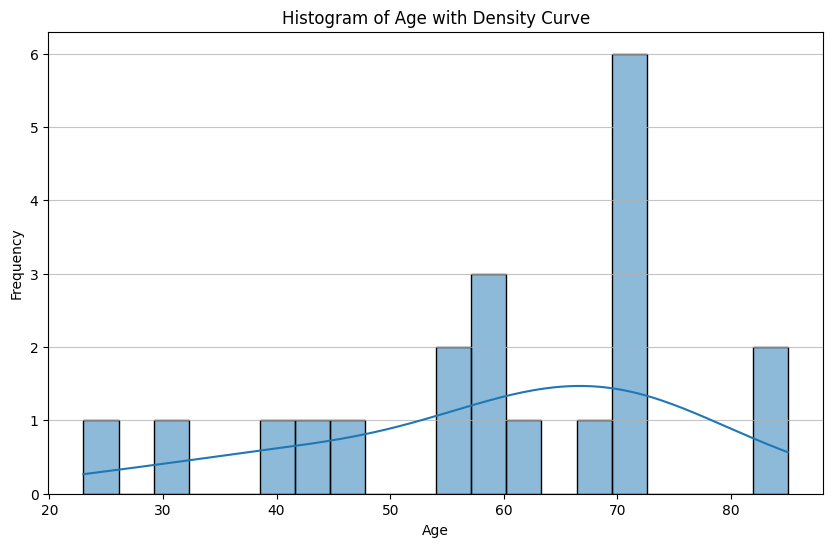

In [22]:
# prompt: Histogram for Age with curve

import matplotlib.pyplot as plt
import seaborn as sns

# Check if 'Age' column exists in the dataframe
if 'Age' in df_preop.columns:
  # Create a histogram with a kernel density estimate curve
  plt.figure(figsize=(10, 6))
  sns.histplot(df_preop['Age'], kde=True, bins=20) # Adjust bins as needed
  plt.title('Histogram of Age with Density Curve')
  plt.xlabel('Age')
  plt.ylabel('Frequency')
  plt.grid(axis='y', alpha=0.75)
  plt.show()
else:
  print("Column 'Age' not found in the DataFrame.")


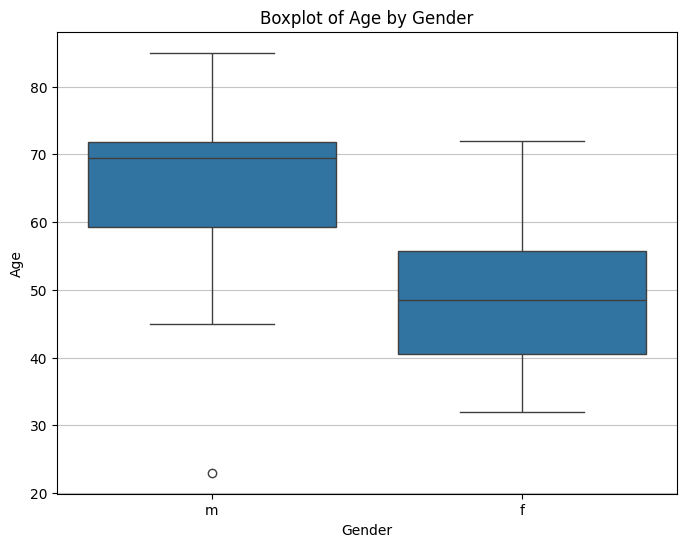

In [23]:
# prompt: Boxplot

import matplotlib.pyplot as plt
# Check if 'Age' and 'Gender' columns exist
if 'Age' in df_preop.columns and 'Gender' in df_preop.columns:
  # Create a boxplot of Age by Gender
  plt.figure(figsize=(8, 6))
  sns.boxplot(x='Gender', y='Age', data=df_preop)
  plt.title('Boxplot of Age by Gender')
  plt.xlabel('Gender')
  plt.ylabel('Age')
  plt.grid(axis='y', alpha=0.75)
  plt.show()
else:
  print("Columns 'Age' or 'Gender' not found in the DataFrame.")

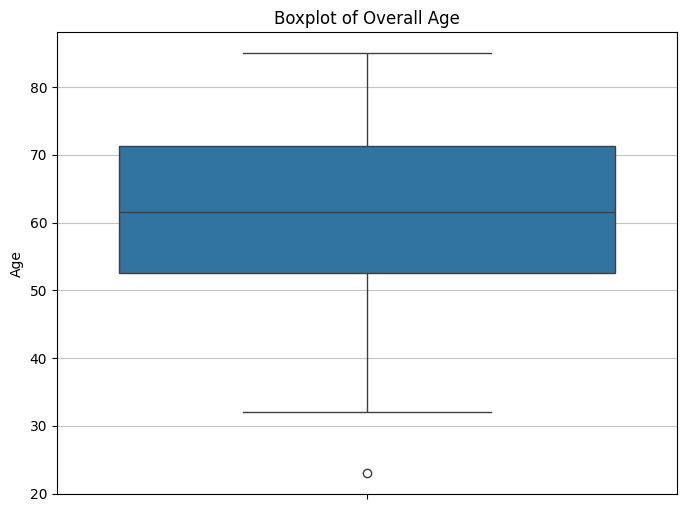

In [24]:
# prompt: Boxplot overall Age

import matplotlib.pyplot as plt
# Check if 'Age' column exists in the dataframe
if 'Age' in df_preop.columns:
  # Create a boxplot for the 'Age' column
  plt.figure(figsize=(8, 6))
  sns.boxplot(y=df_preop['Age'])
  plt.title('Boxplot of Overall Age')
  plt.ylabel('Age')
  plt.grid(axis='y', alpha=0.75)
  plt.show()
else:
  print("Column 'Age' not found in the DataFrame.")

In [25]:
df_preop.columns

Index(['Name', 'Age', 'Gender', 'Eye', 'Diagnosis', 'Min(iJ)', 'Average(iJ)',
       'Max(iJ)', 'Min(as-oct)', 'Average(as-oct)', 'Max(as-oct)', 'VA',
       'LogMar(pre-op)', 'Age.1', 'Gender.1', 'c-min(iJ)', 'c-Average(iJ)',
       'c-max(iJ)', 'Min(as-oct).1', 'Average(as-oct).1', 'Max(as-oct).1',
       'Age_Group', 'Age1_Group'],
      dtype='object')

In [34]:
# prompt: Show columns 'Average(iJ)',
#        Average(as-oct)', 'c-Average(iJ), Average(as-oct).1

# Define the columns to display
columns_to_show = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if the columns exist in the DataFrame before selecting
missing_columns = [col for col in columns_to_show if col not in df_preop.columns]

if not missing_columns:
    # Display the selected columns
    display(df_preop[columns_to_show])
else:
    print(f"The following columns were not found in the DataFrame: {missing_columns}")


,Average(iJ),Average(as-oct),c-Average(iJ),Average(as-oct).1
0,376,555,412.0,545.0
1,320,516,367.0,498.0
2,265,391,370.0,498.0
3,754,927,388.0,534.0
4,245,362,398.0,548.0
5,654,890,402.0,552.0
6,534,751,413.0,558.0
7,201,317,382.0,538.0
8,389,572,411.0,525.0
9,302,456,381.0,503.0


In [40]:
# prompt: Descriptive statistics  'Average(iJ)',
#        'Average(as-oct)',
#        'c-Average(iJ)', Average(as-oct).1
#        'c-max(iJ)', 'Min(as-oct).1', 'Average(as-oct).1', 'Max(as-oct).1

# Define the columns for descriptive statistics
descriptive_preop_iJoct = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1' # This column is repeated, assuming a typo and intended as another relevant column

]

# Remove duplicate column names if any (due to the typo possibility)
descriptive_preop_iJoct = list(dict.fromkeys(descriptive_preop_iJoct))

# Check which of these columns are actually present in the DataFrame
present_descriptive_cols = [col for col in descriptive_preop_iJoct if col in df_preop.columns]

if present_descriptive_cols:
    # Calculate descriptive statistics for the present columns
    descriptive_stats = df_preop[present_descriptive_cols].describe()

    print("\nDescriptive Statistics for prop iJ oct:")
    display(descriptive_stats)

    # You can also get descriptive statistics grouped by 'Gender' if 'Gender' exists
    if 'Gender' in df_preop.columns:
        print("\nDescriptive Statistics for preop iJ oct by Gender:")
        descriptive_stats_by_gender = df_preop.groupby('Gender')[present_descriptive_cols].describe()
        display(descriptive_stats_by_gender)
    else:
        print("\n'Gender' column not found for group-wise descriptive statistics.")

else:
    print("None of the specified columns for descriptive statistics were found in the DataFrame.")



Descriptive Statistics for prop iJ oct:


,Average(iJ),Average(as-oct),c-Average(iJ),Average(as-oct).1
count,20.000000,20.000000,15.000000,15.000000
mean,382.350000,551.750000,389.133333,520.800000
std,140.148521,164.714066,20.566501,25.071897
min,201.000000,317.000000,354.000000,481.000000
25%,304.250000,463.500000,373.000000,498.500000
50%,352.000000,539.000000,388.000000,525.000000
75%,411.250000,589.750000,406.500000,541.500000
max,754.000000,927.000000,421.000000,558.000000



Descriptive Statistics for preop iJ oct by Gender:


Average(iJ)                                                        \
             count        mean         std    min     25%    50%     75%   
Gender                                                                     
f              6.0  299.166667   45.340563  210.0  302.75  312.5  322.25   
m             14.0  418.000000  152.820156  201.0  342.75  387.5  478.00   

              Average(as-oct)              ... c-Average(iJ)         \
          max           count        mean  ...           75%    max   
Gender                                     ...                        
f       335.0             6.0  455.166667  ...        385.25  398.0   
m       754.0            14.0  593.142857  ...        411.50  421.0   

       Average(as-oct).1                                                       \
                   count        mean        std    min     25%    50%     75%   
Gender                                                                          
f                    4.0  503.000000   6.377042  498.0  498.75  501.0  505.25   
m                   11.0  527.272727  26.363197  481.0  511.50  534.0  546.50   

               
          max  
Gender         
f       512.0  
m       558.0  

[2 rows x 32 columns]

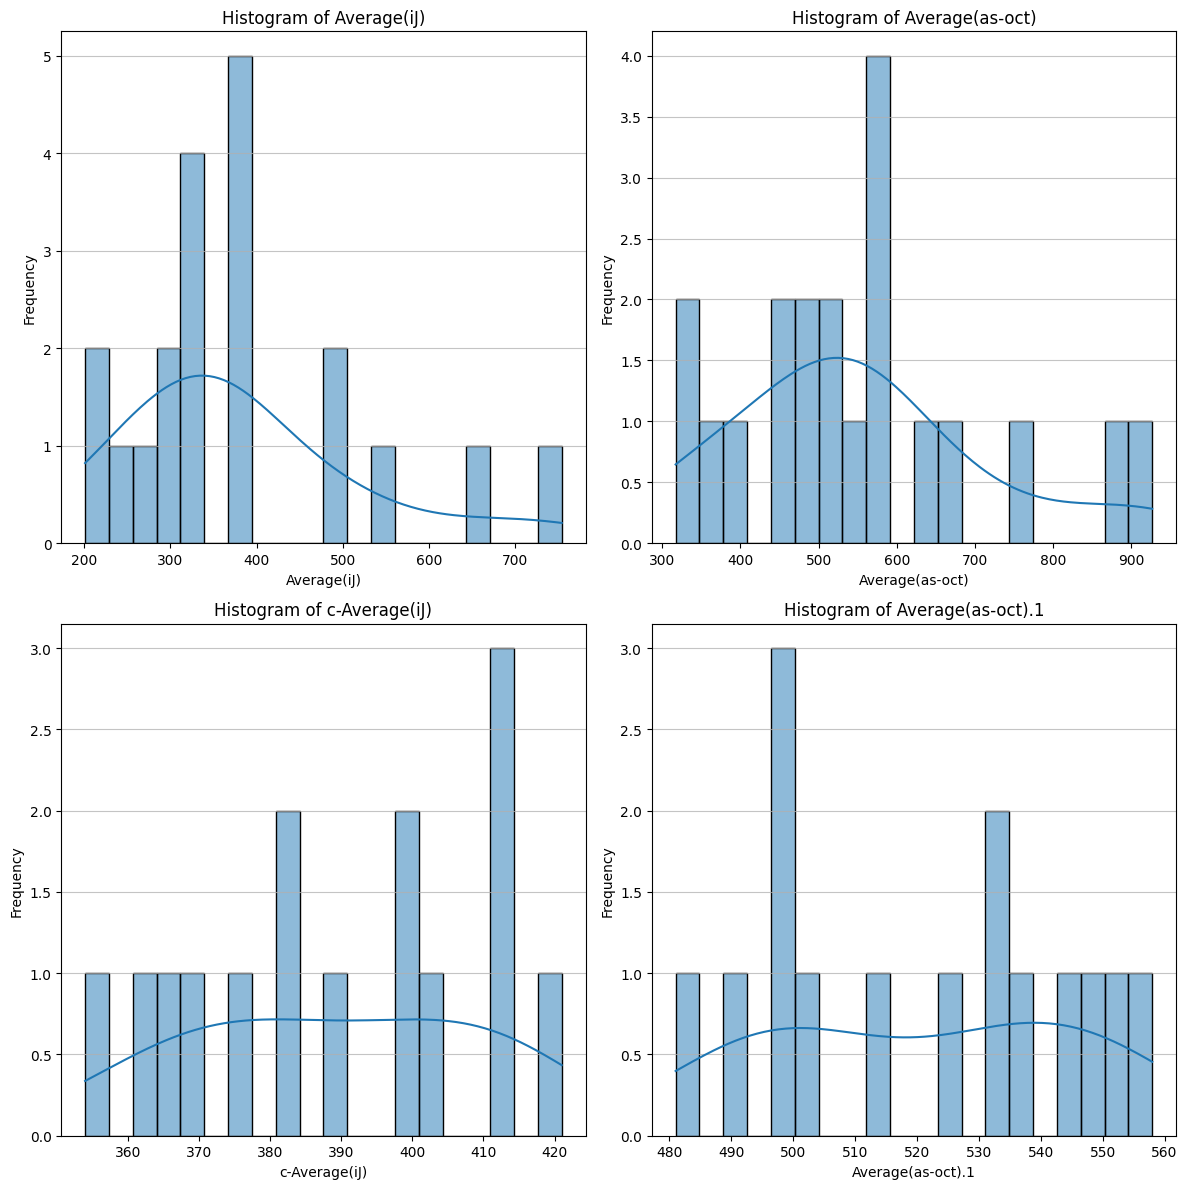

In [46]:
# prompt: Histogram all in one figure

import matplotlib.pyplot as plt
# List of columns to create histograms for
columns_to_histogram = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if the columns exist and filter the list
existing_columns = [col for col in columns_to_histogram if col in df_preop.columns]

if existing_columns:
    # Determine the number of columns to plot
    n_cols = len(existing_columns)
    # Determine the number of rows needed (approximately 2 columns per row)
    n_rows = (n_cols + 1) // 2

    # Create a figure and a set of subplots
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 6 * n_rows)) # Adjust figsize as needed
    axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

    # Iterate through the existing columns and plot a histogram on each subplot
    for i, col in enumerate(existing_columns):
        sns.histplot(df_preop[col], kde=True, bins=20, ax=axes[i]) # Adjust bins as needed
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(axis='y', alpha=0.75)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

else:
    print("None of the specified columns for histogramming were found in the DataFrame.")


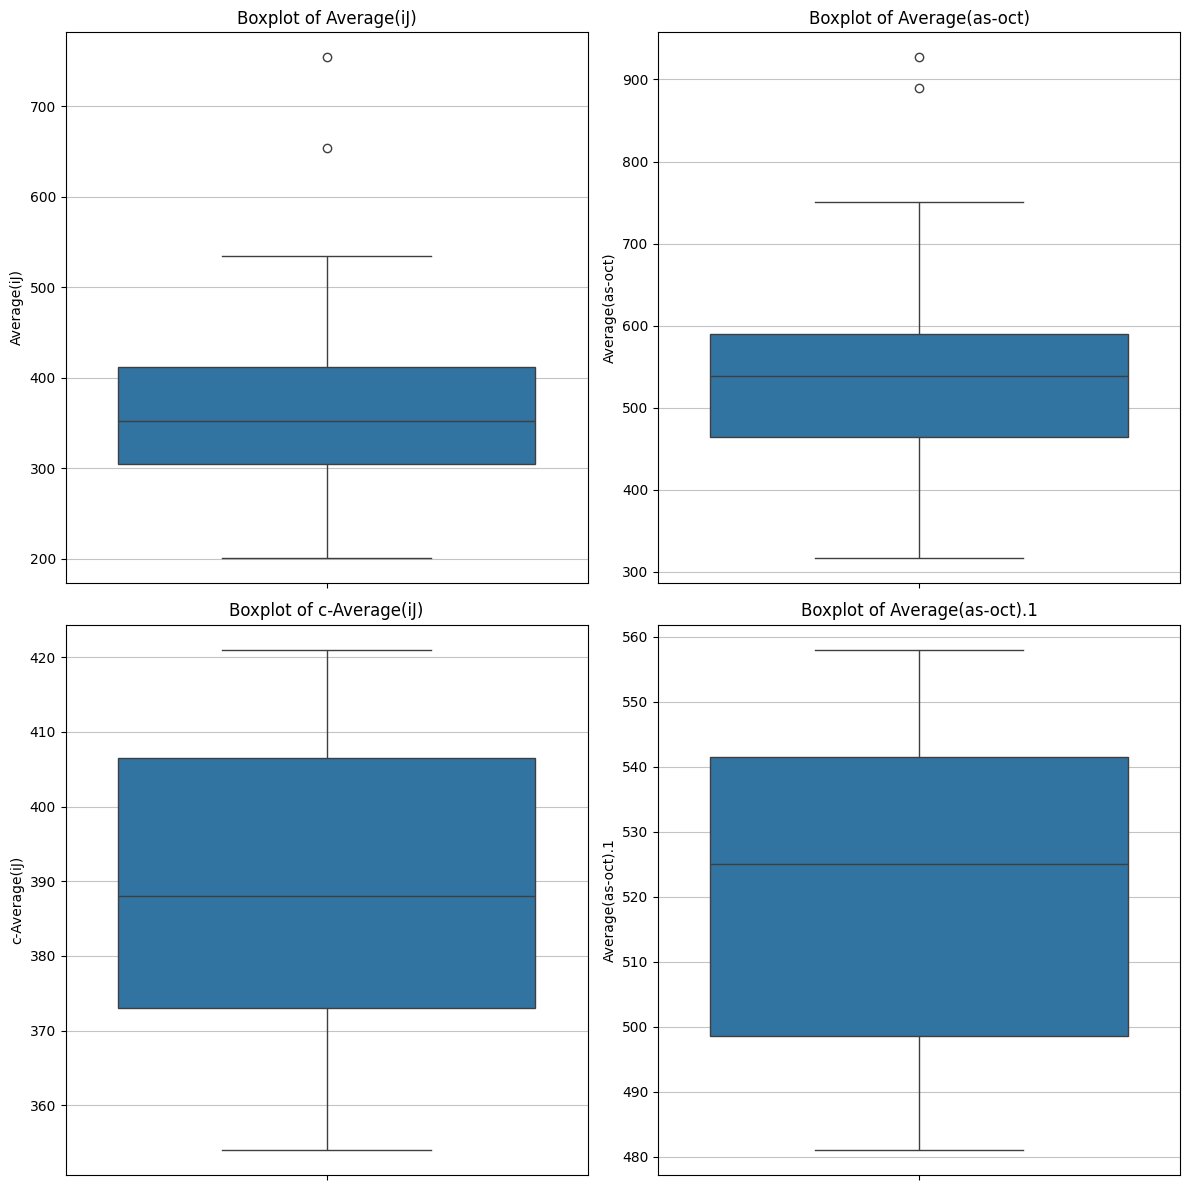


Boxplots for preop iJ oct by Gender:


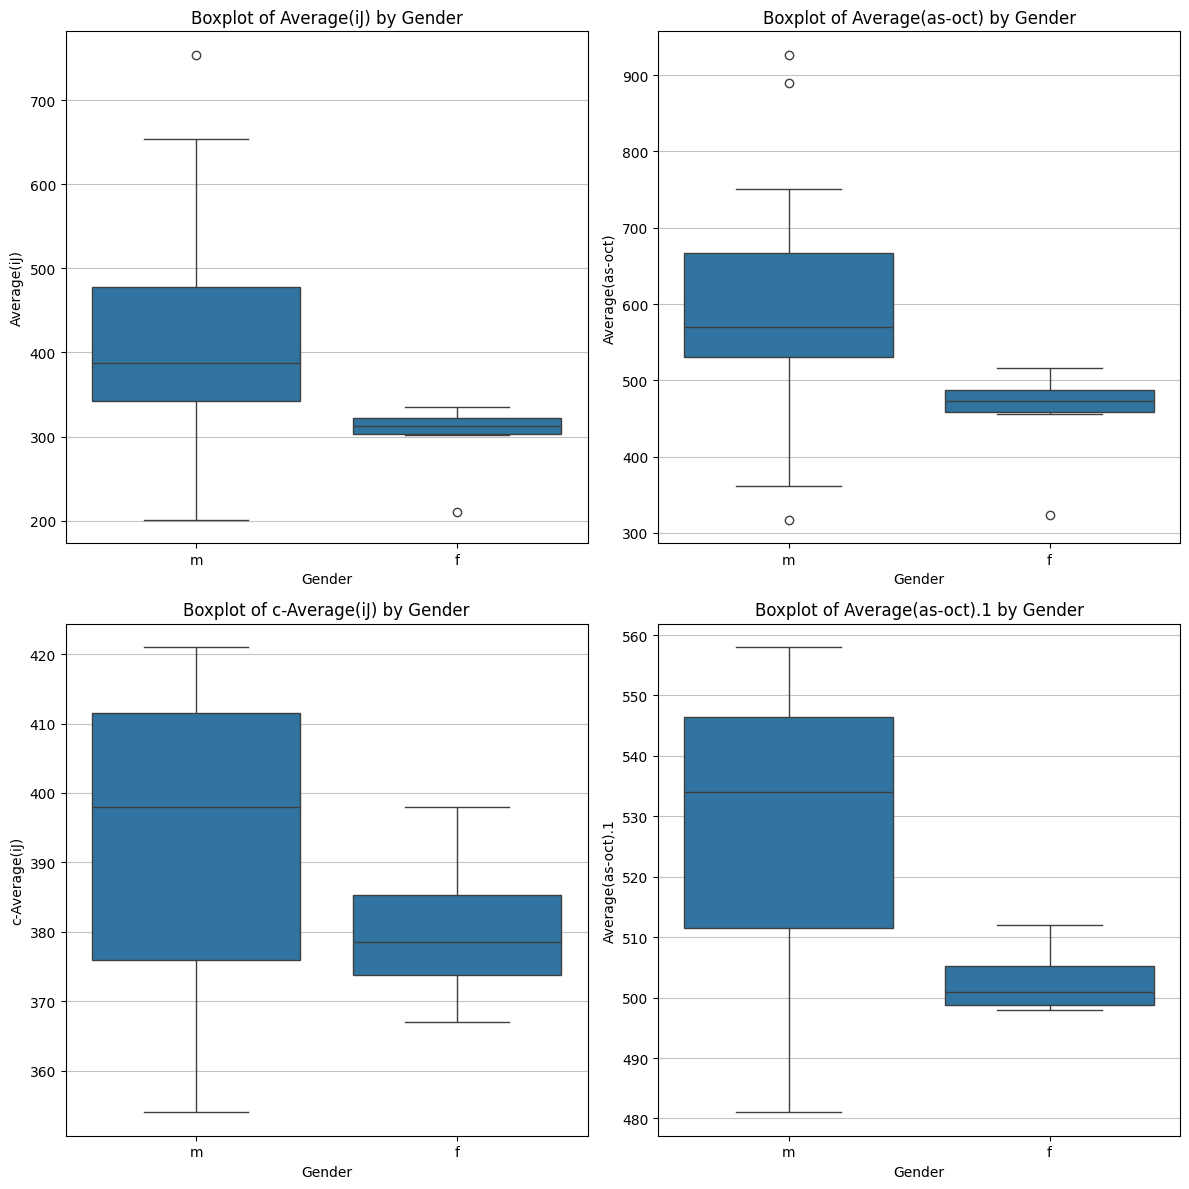

In [47]:
# prompt: Box plots

import matplotlib.pyplot as plt
# List of columns to create box plots for
columns_to_boxplot = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if the columns exist and filter the list
existing_boxplot_columns = [col for col in columns_to_boxplot if col in df_preop.columns]

if existing_boxplot_columns:
    # Determine the number of columns to plot
    n_cols_boxplot = len(existing_boxplot_columns)
    # Determine the number of rows needed (approximately 2 columns per row)
    n_rows_boxplot = (n_cols_boxplot + 1) // 2

    # Create a figure and a set of subplots
    fig_boxplot, axes_boxplot = plt.subplots(n_rows_boxplot, 2, figsize=(12, 6 * n_rows_boxplot)) # Adjust figsize as needed
    axes_boxplot = axes_boxplot.flatten() # Flatten the 2D array of axes for easier iteration

    # Iterate through the existing columns and plot a box plot on each subplot
    for i, col in enumerate(existing_boxplot_columns):
        sns.boxplot(y=df_preop[col], ax=axes_boxplot[i])
        axes_boxplot[i].set_title(f'Boxplot of {col}')
        axes_boxplot[i].set_ylabel(col)
        axes_boxplot[i].grid(axis='y', alpha=0.75)

    # Hide any unused subplots
    for j in range(i + 1, len(axes_boxplot)):
        fig_boxplot.delaxes(axes_boxplot[j])

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

else:
    print("None of the specified columns for box plotting were found in the DataFrame.")

# Create box plots by Gender for the specified columns
if 'Gender' in df_preop.columns and existing_boxplot_columns:
    print("\nBoxplots for preop iJ oct by Gender:")

    # Determine the number of columns to plot per gender
    n_cols_gender_boxplot = len(existing_boxplot_columns)
    # Determine the number of rows needed (approximately 2 columns per row per gender)
    n_rows_gender_boxplot = (n_cols_gender_boxplot + 1) // 2

    # Create a figure and a set of subplots
    fig_gender_boxplot, axes_gender_boxplot = plt.subplots(n_rows_gender_boxplot, 2, figsize=(12, 6 * n_rows_gender_boxplot)) # Adjust figsize as needed
    axes_gender_boxplot = axes_gender_boxplot.flatten() # Flatten the 2D array of axes for easier iteration

    # Iterate through the existing columns and plot a box plot by Gender on each subplot
    for i, col in enumerate(existing_boxplot_columns):
        sns.boxplot(x='Gender', y=col, data=df_preop, ax=axes_gender_boxplot[i])
        axes_gender_boxplot[i].set_title(f'Boxplot of {col} by Gender')
        axes_gender_boxplot[i].set_xlabel('Gender')
        axes_gender_boxplot[i].set_ylabel(col)
        axes_gender_boxplot[i].grid(axis='y', alpha=0.75)

    # Hide any unused subplots
    for j in range(i + 1, len(axes_gender_boxplot)):
        fig_gender_boxplot.delaxes(axes_gender_boxplot[j])

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

elif 'Gender' not in df_preop.columns:
    print("\n'Gender' column not found for group-wise box plots.")
else:
    print("\nNone of the specified columns for box plotting by Gender were found in the DataFrame.")

In [56]:
df_preop.columns

Index(['Name', 'Age', 'Gender', 'Eye', 'Diagnosis', 'Min(iJ)', 'Average(iJ)',
       'Max(iJ)', 'Min(as-oct)', 'Average(as-oct)', 'Max(as-oct)', 'VA',
       'LogMar(pre-op)', 'Age.1', 'Gender.1', 'c-min(iJ)', 'c-Average(iJ)',
       'c-max(iJ)', 'Min(as-oct).1', 'Average(as-oct).1', 'Max(as-oct).1',
       'Age_Group', 'Age1_Group'],
      dtype='object')

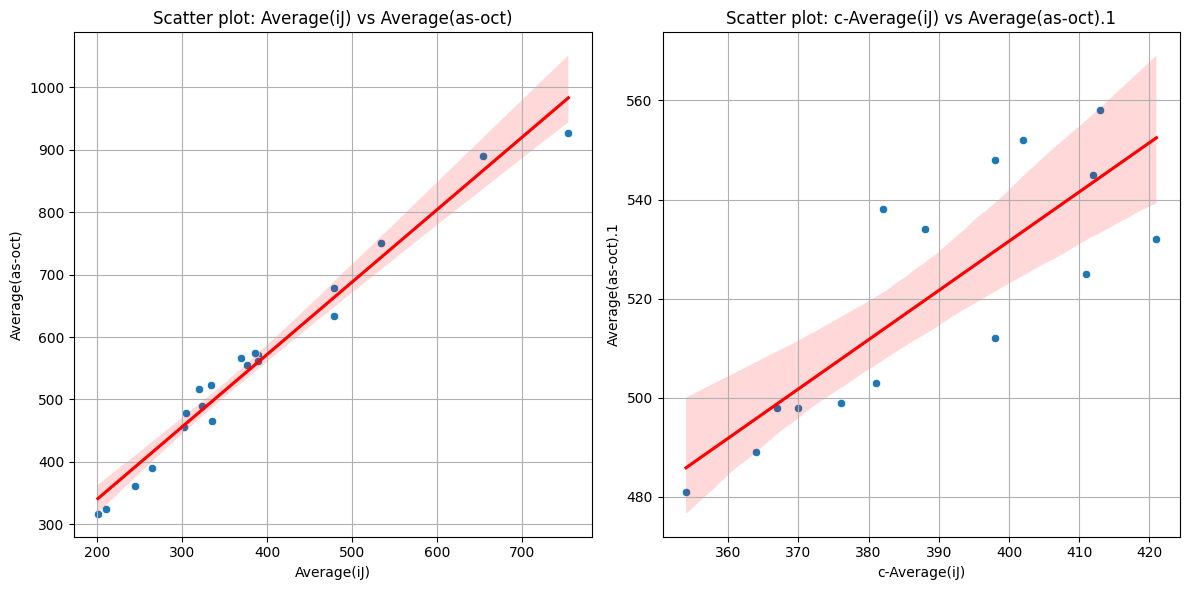

In [67]:
# prompt: Scatter 'plots Average(iJ)', 'Average(as-oct)',
#     c-Average(iJ)', Average(as-oct).1', side by side with line

import matplotlib.pyplot as plt
# Scatter plots side by side with line
columns_to_scatter = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if the columns exist and filter the list
existing_scatter_columns = [col for col in columns_to_scatter if col in df_preop.columns]

if len(existing_scatter_columns) >= 2:
    # Determine the number of pairs to plot
    # We will plot (Average(iJ) vs Average(as-oct)) and (c-Average(iJ) vs Average(as-oct).1)
    pairs_to_plot = [
        ('Average(iJ)', 'Average(as-oct)'),
        ('c-Average(iJ)', 'Average(as-oct).1')
    ]

    # Filter pairs to include only those where both columns exist
    valid_pairs = [(col1, col2) for col1, col2 in pairs_to_plot if col1 in df_preop.columns and col2 in df_preop.columns]

    if valid_pairs:
        # Create a figure and a set of subplots (1 row, number of valid pairs columns)
        fig_scatter, axes_scatter = plt.subplots(1, len(valid_pairs), figsize=(6 * len(valid_pairs), 6)) # Adjust figsize as needed

        # Ensure axes_scatter is an array even if there's only one subplot
        if len(valid_pairs) == 1:
            axes_scatter = [axes_scatter]

        # Iterate through the valid pairs and plot a scatter plot on each subplot
        for i, (col_x, col_y) in enumerate(valid_pairs):
            # Scatter plot
            sns.scatterplot(x=df_preop[col_x], y=df_preop[col_y], ax=axes_scatter[i])

            # Add a regression line for the trend
            sns.regplot(x=df_preop[col_x], y=df_preop[col_y], scatter=False, color='red', ax=axes_scatter[i])


            axes_scatter[i].set_title(f'Scatter plot: {col_x} vs {col_y}')
            axes_scatter[i].set_xlabel(col_x)
            axes_scatter[i].set_ylabel(col_y)
            axes_scatter[i].grid(True)

        plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
        plt.show()

    else:
         print("None of the specified column pairs for scatter plotting were found in the DataFrame.")

else:
    print("Not enough specified columns were found in the DataFrame to create scatter plots.")

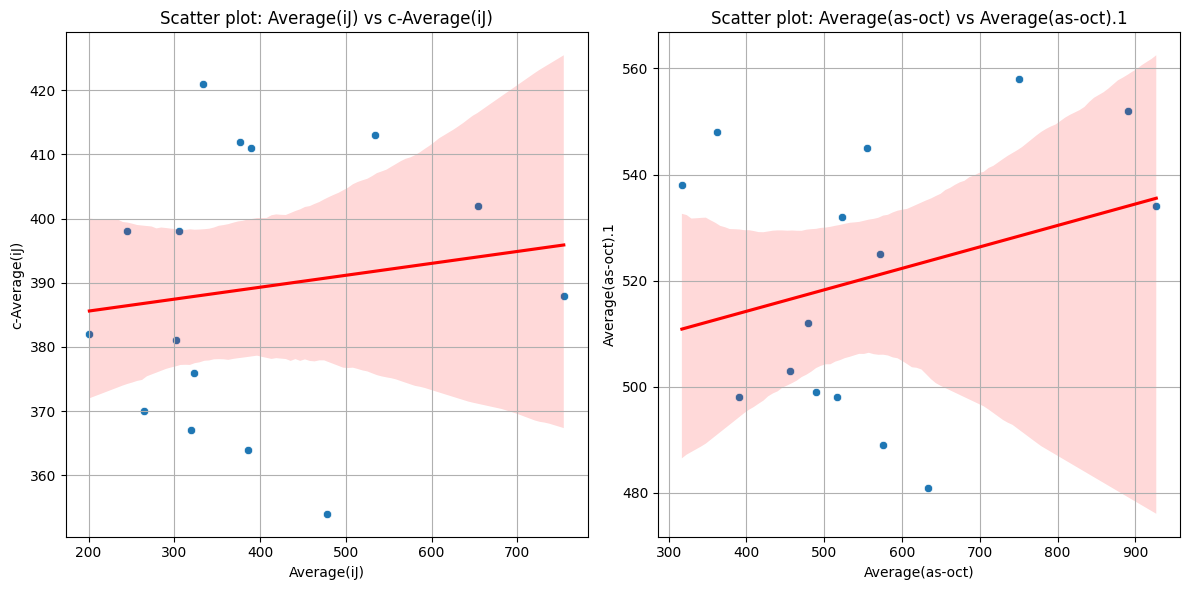

In [68]:
# prompt: Scatter 'plots Average(iJ)', 'c-Average(iJ)',
#     Average('as-oct), Average(as-oct).1', side by side with line

import matplotlib.pyplot as plt
# Scatter plots side by side with line
columns_to_scatter = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if the columns exist and filter the list
existing_scatter_columns = [col for col in columns_to_scatter if col in df_preop.columns]

if len(existing_scatter_columns) >= 2:
    # Define the pairs to plot
    # We will plot (Average(iJ) vs c-Average(iJ)) and (Average(as-oct) vs Average(as-oct).1)
    pairs_to_plot = [
        ('Average(iJ)', 'c-Average(iJ)'),
        ('Average(as-oct)', 'Average(as-oct).1')
    ]

    # Filter pairs to include only those where both columns exist
    valid_pairs = [(col1, col2) for col1, col2 in pairs_to_plot if col1 in df_preop.columns and col2 in df_preop.columns]

    if valid_pairs:
        # Create a figure and a set of subplots (1 row, number of valid pairs columns)
        fig_scatter, axes_scatter = plt.subplots(1, len(valid_pairs), figsize=(6 * len(valid_pairs), 6)) # Adjust figsize as needed

        # Ensure axes_scatter is an array even if there's only one subplot
        if len(valid_pairs) == 1:
            axes_scatter = [axes_scatter]

        # Iterate through the valid pairs and plot a scatter plot on each subplot
        for i, (col_x, col_y) in enumerate(valid_pairs):
            # Scatter plot
            sns.scatterplot(x=df_preop[col_x], y=df_preop[col_y], ax=axes_scatter[i])

            # Add a regression line for the trend
            sns.regplot(x=df_preop[col_x], y=df_preop[col_y], scatter=False, color='red', ax=axes_scatter[i])

            axes_scatter[i].set_title(f'Scatter plot: {col_x} vs {col_y}')
            axes_scatter[i].set_xlabel(col_x)
            axes_scatter[i].set_ylabel(col_y)
            axes_scatter[i].grid(True)

        plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
        plt.show()

    else:
         print("None of the specified column pairs for scatter plotting were found in the DataFrame.")

else:
    print("Not enough specified columns were found in the DataFrame to create scatter plots.")



Correlation Matrix:


,Average(iJ),Average(as-oct),c-Average(iJ),Average(as-oct).1
Average(iJ),1.000000,0.987190,0.138941,0.279504
Average(as-oct),0.987190,1.000000,0.188702,0.285330
c-Average(iJ),0.138941,0.188702,1.000000,0.815406
Average(as-oct).1,0.279504,0.285330,0.815406,1.000000


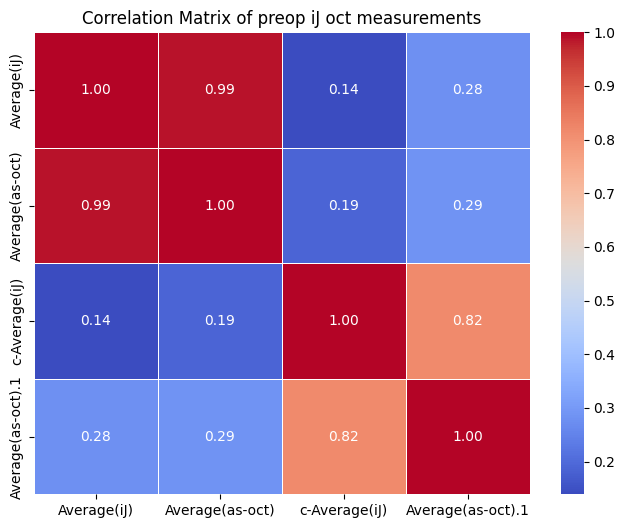

In [69]:
# prompt: Correlation

import matplotlib.pyplot as plt
# List of columns for correlation analysis
correlation_columns = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if the columns exist and filter the list
existing_correlation_columns = [col for col in correlation_columns if col in df_preop.columns]

if existing_correlation_columns:
    # Calculate the correlation matrix for the existing columns
    correlation_matrix = df_preop[existing_correlation_columns].corr()

    print("\nCorrelation Matrix:")
    display(correlation_matrix)

    # Create a heatmap for the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of preop iJ oct measurements')
    plt.show()

else:
    print("None of the specified columns for correlation analysis were found in the DataFrame.")

In [70]:
# prompt: t test

from scipy import stats

# Perform independent t-test on 'Average(iJ)' and 'c-Average(iJ)'
# Check if the columns exist
if 'Average(iJ)' in df_preop.columns and 'c-Average(iJ)' in df_preop.columns:
  # Drop NaN values from both columns before the test
  group1 = df_preop['Average(iJ)'].dropna()
  group2 = df_preop['c-Average(iJ)'].dropna()

  # Perform the independent samples t-test
  # Assuming unequal variances (Welch's t-test) which is generally safer unless you have strong reasons to assume equal variances.
  # For equal variances, use equal_var=True
  ttest_ij_cij = stats.ttest_ind(group1, group2, equal_var=False)

  print("\nIndependent t-test between Average(iJ) and c-Average(iJ):")
  print(f"  T-statistic: {ttest_ij_cij.statistic:.4f}")
  print(f"  P-value: {ttest_ij_cij.pvalue:.4f}")

  # Interpret the result
  alpha = 0.05
  if ttest_ij_cij.pvalue < alpha:
      print(f"  Result: The p-value ({ttest_ij_cij.pvalue:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
      print("  Conclusion: There is a statistically significant difference between Average(iJ) and c-Average(iJ).")
  else:
      print(f"  Result: The p-value ({ttest_ij_cij.pvalue:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
      print("  Conclusion: There is no statistically significant difference between Average(iJ) and c-Average(iJ).")

else:
  print("Columns 'Average(iJ)' or 'c-Average(iJ)' not found in the DataFrame for t-test.")

# Perform independent t-test on 'Average(as-oct)' and 'Average(as-oct).1'
# Check if the columns exist
if 'Average(as-oct)' in df_preop.columns and 'Average(as-oct).1' in df_preop.columns:
  # Drop NaN values from both columns before the test
  group1_oct = df_preop['Average(as-oct)'].dropna()
  group2_oct = df_preop['Average(as-oct).1'].dropna()

  # Perform the independent samples t-test
  ttest_oct_oct1 = stats.ttest_ind(group1_oct, group2_oct, equal_var=False)

  print("\nIndependent t-test between Average(as-oct) and Average(as-oct).1:")
  print(f"  T-statistic: {ttest_oct_oct1.statistic:.4f}")
  print(f"  P-value: {ttest_oct_oct1.pvalue:.4f}")

  # Interpret the result
  alpha = 0.05
  if ttest_oct_oct1.pvalue < alpha:
      print(f"  Result: The p-value ({ttest_oct_oct1.pvalue:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
      print("  Conclusion: There is a statistically significant difference between Average(as-oct) and Average(as-oct).1.")
  else:
      print(f"  Result: The p-value ({ttest_oct_oct1.pvalue:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
      print("  Conclusion: There is no statistically significant difference between Average(as-oct) and Average(as-oct).1.")

else:
  print("Columns 'Average(as-oct)' or 'Average(as-oct).1' not found in the DataFrame for t-test.")

# Perform independent t-tests for the specified columns, grouped by 'Gender'
t_test_columns_gender = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

if 'Gender' in df_preop.columns:
    print("\nPerforming independent t-tests for selected columns, grouped by Gender:")

    # Filter columns that exist in the DataFrame
    existing_t_test_columns_gender = [col for col in t_test_columns_gender if col in df_preop.columns]

    if existing_t_test_columns_gender:
        # Get unique gender values (excluding potential NaNs)
        genders = df_preop['Gender'].dropna().unique()

        # Ensure there are at least two gender groups to compare
        if len(genders) >= 2:
            # Assume the first two genders are the ones to compare (e.g., 'Male' and 'Female')
            # You might need to adjust this if your 'Gender' column has more categories or different names
            gender1 = genders[0]
            gender2 = genders[1]

            print(f"  Comparing groups: '{gender1}' and '{gender2}'")

            for col in existing_t_test_columns_gender:
                # Get the data for each gender group, dropping NaNs for the current column
                group1_data = df_preop[df_preop['Gender'] == gender1][col].dropna()
                group2_data = df_preop[df_preop['Gender'] == gender2][col].dropna()

                # Ensure both groups have data
                if len(group1_data) > 1 and len(group2_data) > 1: # Need at least 2 samples for t-test
                    # Perform the independent samples t-test
                    ttest_gender = stats.ttest_ind(group1_data, group2_data, equal_var=False)

                    print(f"\n  T-test for '{col}' between '{gender1}' and '{gender2}':")
                    print(f"    T-statistic: {ttest_gender.statistic:.4f}")
                    print(f"    P-value: {ttest_gender.pvalue:.4f}")

                    # Interpret the result
                    alpha = 0.05
                    if ttest_gender.pvalue < alpha:
                        print(f"    Result: The p-value ({ttest_gender.pvalue:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                        print(f"    Conclusion: There is a statistically significant difference in '{col}' between '{gender1}' and '{gender2}'.")
                    else:
                        print(f"    Result: The p-value ({ttest_gender.pvalue:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                        print(f"    Conclusion: There is no statistically significant difference in '{col}' between '{gender1}' and '{gender2}'.")
                else:
                    print(f"\n  Not enough data in one or both groups for '{col}' to perform t-test.")
        else:
            print("\n'Gender' column does not have at least two distinct groups to compare.")
    else:
        print("\nNone of the specified columns for gender-based t-tests were found in the DataFrame.")
else:
    print("\n'Gender' column not found in the DataFrame to perform gender-based t-tests.")



Independent t-test between Average(iJ) and c-Average(iJ):
  T-statistic: -0.2134
  P-value: 0.8332
  Result: The p-value (0.8332) is greater than the significance level (0.05). We fail to reject the null hypothesis.
  Conclusion: There is no statistically significant difference between Average(iJ) and c-Average(iJ).

Independent t-test between Average(as-oct) and Average(as-oct).1:
  T-statistic: 0.8276
  P-value: 0.4176
  Result: The p-value (0.4176) is greater than the significance level (0.05). We fail to reject the null hypothesis.
  Conclusion: There is no statistically significant difference between Average(as-oct) and Average(as-oct).1.

Performing independent t-tests for selected columns, grouped by Gender:
  Comparing groups: 'm' and 'f'

  T-test for 'Average(iJ)' between 'm' and 'f':
    T-statistic: 2.6501
    P-value: 0.0168
    Result: The p-value (0.0168) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically 

In [71]:
# prompt: t test

# List of columns to perform paired t-tests on
paired_t_test_columns = [
    ('Average(iJ)', 'Average(as-oct)'),
    ('c-Average(iJ)', 'Average(as-oct).1')
]

print("\nPerforming paired t-tests:")

for col1, col2 in paired_t_test_columns:
    # Check if both columns exist
    if col1 in df_preop.columns and col2 in df_preop.columns:
        # Create a temporary DataFrame with only the two columns, dropping rows with NaN in either column
        temp_df = df_preop[[col1, col2]].dropna()

        # Ensure there is enough data after dropping NaNs
        if len(temp_df) > 1: # Paired t-test requires at least 2 pairs
            # Perform the paired samples t-test
            ttest_paired = stats.ttest_rel(temp_df[col1], temp_df[col2])

            print(f"\n  Paired t-test between '{col1}' and '{col2}':")
            print(f"    T-statistic: {ttest_paired.statistic:.4f}")
            print(f"    P-value: {ttest_paired.pvalue:.4f}")

            # Interpret the result
            alpha = 0.05
            if ttest_paired.pvalue < alpha:
                print(f"    Result: The p-value ({ttest_paired.pvalue:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                print(f"    Conclusion: There is a statistically significant difference between '{col1}' and '{col2}'.")
            else:
                print(f"    Result: The p-value ({ttest_paired.pvalue:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                print(f"    Conclusion: There is no statistically significant difference between '{col1}' and '{col2}'.")
        else:
            print(f"\n  Not enough paired data for '{col1}' and '{col2}' to perform paired t-test after dropping NaNs.")
    else:
        print(f"\n  Columns '{col1}' or '{col2}' not found in the DataFrame for paired t-test.")


Performing paired t-tests:

  Paired t-test between 'Average(iJ)' and 'Average(as-oct)':
    T-statistic: -21.9162
    P-value: 0.0000
    Result: The p-value (0.0000) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference between 'Average(iJ)' and 'Average(as-oct)'.

  Paired t-test between 'c-Average(iJ)' and 'Average(as-oct).1':
    T-statistic: -35.1337
    P-value: 0.0000
    Result: The p-value (0.0000) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference between 'c-Average(iJ)' and 'Average(as-oct).1'.


In [72]:
# prompt: Interpret t test

print("Interpretation of t-tests:")

print("\nInterpretation of Independent t-test between Average(iJ) and c-Average(iJ):")
if 'Average(iJ)' in df_preop.columns and 'c-Average(iJ)' in df_preop.columns:
    # Re-perform the t-test to get the p-value if the previous output is not available
    group1 = df_preop['Average(iJ)'].dropna()
    group2 = df_preop['c-Average(iJ)'].dropna()

    if len(group1) > 1 and len(group2) > 1:
        ttest_ij_cij = stats.ttest_ind(group1, group2, equal_var=False)
        alpha = 0.05
        if ttest_ij_cij.pvalue < alpha:
            print(f"  Since the p-value ({ttest_ij_cij.pvalue:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
            print("  This suggests there is a statistically significant difference in the mean values of 'Average(iJ)' and 'c-Average(iJ)'.")
        else:
            print(f"  Since the p-value ({ttest_ij_cij.pvalue:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
            print("  This suggests there is no statistically significant difference in the mean values of 'Average(iJ)' and 'c-Average(iJ)'.")
    else:
        print("  Not enough data in one or both groups to interpret the t-test result.")
else:
    print("  Required columns not found to interpret this t-test.")

print("\nInterpretation of Independent t-test between Average(as-oct) and Average(as-oct).1:")
if 'Average(as-oct)' in df_preop.columns and 'Average(as-oct).1' in df_preop.columns:
    # Re-perform the t-test if needed
    group1_oct = df_preop['Average(as-oct)'].dropna()
    group2_oct = df_preop['Average(as-oct).1'].dropna()

    if len(group1_oct) > 1 and len(group2_oct) > 1:
        ttest_oct_oct1 = stats.ttest_ind(group1_oct, group2_oct, equal_var=False)
        alpha = 0.05
        if ttest_oct_oct1.pvalue < alpha:
            print(f"  Since the p-value ({ttest_oct_oct1.pvalue:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
            print("  This suggests there is a statistically significant difference in the mean values of 'Average(as-oct)' and 'Average(as-oct).1'.")
        else:
            print(f"  Since the p-value ({ttest_oct_oct1.pvalue:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
            print("  This suggests there is no statistically significant difference in the mean values of 'Average(as-oct)' and 'Average(as-oct).1'.")
    else:
        print("  Not enough data in one or both groups to interpret the t-test result.")
else:
    print("  Required columns not found to interpret this t-test.")

print("\nInterpretation of Independent t-tests for selected columns, grouped by Gender:")
t_test_columns_gender = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]
existing_t_test_columns_gender = [col for col in t_test_columns_gender if col in df_preop.columns]

if 'Gender' in df_preop.columns and existing_t_test_columns_gender:
    genders = df_preop['Gender'].dropna().unique()
    if len(genders) >= 2:
        gender1 = genders[0]
        gender2 = genders[1]

        for col in existing_t_test_columns_gender:
            group1_data = df_preop[df_preop['Gender'] == gender1][col].dropna()
            group2_data = df_preop[df_preop['Gender'] == gender2][col].dropna()

            if len(group1_data) > 1 and len(group2_data) > 1:
                ttest_gender = stats.ttest_ind(group1_data, group2_data, equal_var=False)
                alpha = 0.05
                print(f"\n  Interpretation for '{col}' between '{gender1}' and '{gender2}':")
                if ttest_gender.pvalue < alpha:
                    print(f"    The p-value ({ttest_gender.pvalue:.4f}) is less than {alpha}, indicating a statistically significant difference in the mean of '{col}' between '{gender1}' and '{gender2}'.")
                else:
                    print(f"    The p-value ({ttest_gender.pvalue:.4f}) is greater than or equal to {alpha}, indicating no statistically significant difference in the mean of '{col}' between '{gender1}' and '{gender2}'.")
            else:
                print(f"\n  Not enough data for '{col}' in one or both gender groups to provide a meaningful interpretation.")
    else:
        print("  'Gender' column does not have at least two distinct groups to compare for interpretation.")
else:
    print("  Required columns or 'Gender' column not found to interpret gender-based t-tests.")


print("\nInterpretation of Paired t-tests:")
paired_t_test_columns = [
    ('Average(iJ)', 'Average(as-oct)'),
    ('c-Average(iJ)', 'Average(as-oct).1')
]

for col1, col2 in paired_t_test_columns:
    if col1 in df_preop.columns and col2 in df_preop.columns:
        temp_df = df_preop[[col1, col2]].dropna()
        if len(temp_df) > 1:
            ttest_paired = stats.ttest_rel(temp_df[col1], temp_df[col2])
            alpha = 0.05
            print(f"\n  Interpretation of Paired t-test between '{col1}' and '{col2}':")
            if ttest_paired.pvalue < alpha:
                print(f"    The p-value ({ttest_paired.pvalue:.4f}) is less than {alpha}, indicating a statistically significant difference between the paired observations of '{col1}' and '{col2}'. This suggests a consistent change or difference within the subjects.")
            else:
                print(f"    The p-value ({ttest_paired.pvalue:.4f}) is greater than or equal to {alpha}, indicating no statistically significant difference between the paired observations of '{col1}' and '{col2}'. This suggests no consistent change or difference within the subjects.")
        else:
            print(f"\n  Not enough paired data for '{col1}' and '{col2}' to provide a meaningful interpretation of the paired t-test.")
    else:
        print(f"\n  Required columns '{col1}' or '{col2}' not found in the DataFrame to interpret the paired t-test.")


Interpretation of t-tests:

Interpretation of Independent t-test between Average(iJ) and c-Average(iJ):
  Since the p-value (0.8332) is greater than the significance level (0.05), we fail to reject the null hypothesis.
  This suggests there is no statistically significant difference in the mean values of 'Average(iJ)' and 'c-Average(iJ)'.

Interpretation of Independent t-test between Average(as-oct) and Average(as-oct).1:
  Since the p-value (0.4176) is greater than the significance level (0.05), we fail to reject the null hypothesis.
  This suggests there is no statistically significant difference in the mean values of 'Average(as-oct)' and 'Average(as-oct).1'.

Interpretation of Independent t-tests for selected columns, grouped by Gender:

  Interpretation for 'Average(iJ)' between 'm' and 'f':
    The p-value (0.0168) is less than 0.05, indicating a statistically significant difference in the mean of 'Average(iJ)' between 'm' and 'f'.

  Interpretation for 'Average(as-oct)' between 

In [74]:
# prompt: Anovs

# Define the columns for ANOVA
anova_columns = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if the columns exist and filter the list
existing_anova_columns = [col for col in anova_columns if col in df_preop.columns]

# Check if 'Gender' column exists for group comparisons
if 'Gender' in df_preop.columns and existing_anova_columns:
    print("\nPerforming One-Way ANOVA for selected columns, grouped by Gender:")

    # Get unique gender values (excluding potential NaNs)
    genders = df_preop['Gender'].dropna().unique()

    # Ensure there are at least two gender groups to compare
    if len(genders) >= 2:
        for col in existing_anova_columns:
            # Create a list of data arrays, one for each gender group for the current column
            anova_data = []
            valid_groups_for_col = []
            for gender in genders:
                group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
                if len(group_data) > 0: # Only include groups with data
                    anova_data.append(group_data)
                    valid_groups_for_col.append(gender)

            # Perform ANOVA only if there are at least two valid groups with data
            if len(anova_data) >= 2:
                # Perform the one-way ANOVA test
                fvalue, pvalue = stats.f_oneway(*anova_data)

                print(f"\n  One-Way ANOVA for '{col}' by Gender ({', '.join(valid_groups_for_col)}):")
                print(f"    F-statistic: {fvalue:.4f}")
                print(f"    P-value: {pvalue:.4f}")

                # Interpret the result
                alpha = 0.05
                if pvalue < alpha:
                    print(f"    Result: The p-value ({pvalue:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                    print(f"    Conclusion: There is a statistically significant difference in '{col}' across the different Gender groups.")
                else:
                    print(f"    Result: The p-value ({pvalue:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                    print(f"    Conclusion: There is no statistically significant difference in '{col}' across the different Gender groups.")
            else:
                print(f"\n  Not enough valid gender groups with data for '{col}' to perform ANOVA.")
    else:
        print("\n'Gender' column does not have at least two distinct groups to compare for ANOVA.")
else:
    if 'Gender' not in df_preop.columns:
      print("\n'Gender' column not found in the DataFrame to perform ANOVA.")
    else:
      print("\nNone of the specified columns for ANOVA were found in the DataFrame.")


print("\nInterpretation of One-Way ANOVA for selected columns, grouped by Gender:")
if 'Gender' in df_preop.columns and existing_anova_columns:
    genders = df_preop['Gender'].dropna().unique()
    if len(genders) >= 2:
         for col in existing_anova_columns:
            anova_data = []
            valid_groups_for_col = []
            for gender in genders:
                group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
                if len(group_data) > 0:
                    anova_data.append(group_data)
                    valid_groups_for_col.append(gender)

            if len(anova_data) >= 2:
                fvalue, pvalue = stats.f_oneway(*anova_data)
                alpha = 0.05
                print(f"\n  Interpretation for '{col}' by Gender ({', '.join(valid_groups_for_col)}):")
                if pvalue < alpha:
                    print(f"    The p-value ({pvalue:.4f}) is less than {alpha}. This indicates that there is a statistically significant difference in the mean of '{col}' between at least two of the gender groups.")
                else:
                    print(f"    The p-value ({pvalue:.4f}) is greater than or equal to {alpha}. This indicates that there is no statistically significant difference in the mean of '{col}' between the gender groups.")
            else:
                print(f"\n  Not enough valid gender groups with data for '{col}' to provide a meaningful interpretation.")
    else:
        print("  'Gender' column does not have at least two distinct groups to compare for interpretation.")
else:
    print("  Required columns or 'Gender' column not found to interpret gender-based ANOVA.")



Performing One-Way ANOVA for selected columns, grouped by Gender:

  One-Way ANOVA for 'Average(iJ)' by Gender (m, f):
    F-statistic: 3.4012
    P-value: 0.0817
    Result: The p-value (0.0817) is greater than the significance level (0.05). We fail to reject the null hypothesis.
    Conclusion: There is no statistically significant difference in 'Average(iJ)' across the different Gender groups.

  One-Way ANOVA for 'Average(as-oct)' by Gender (m, f):
    F-statistic: 3.3046
    P-value: 0.0858
    Result: The p-value (0.0858) is greater than the significance level (0.05). We fail to reject the null hypothesis.
    Conclusion: There is no statistically significant difference in 'Average(as-oct)' across the different Gender groups.

  One-Way ANOVA for 'c-Average(iJ)' by Gender (m, f):
    F-statistic: 0.9583
    P-value: 0.3455
    Result: The p-value (0.3455) is greater than the significance level (0.05). We fail to reject the null hypothesis.
    Conclusion: There is no statistical


Regression Analysis: Predicting 'Average(as-oct)' using 'Average(iJ)'
                            OLS Regression Results                            
Dep. Variable:        Average(as-oct)   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     689.1
Date:                Sun, 13 Jul 2025   Prob (F-statistic):           8.42e-16
Time:                        17:59:54   Log-Likelihood:                -93.242
No. Observations:                  20   AIC:                             190.5
Df Residuals:                      18   BIC:                             192.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

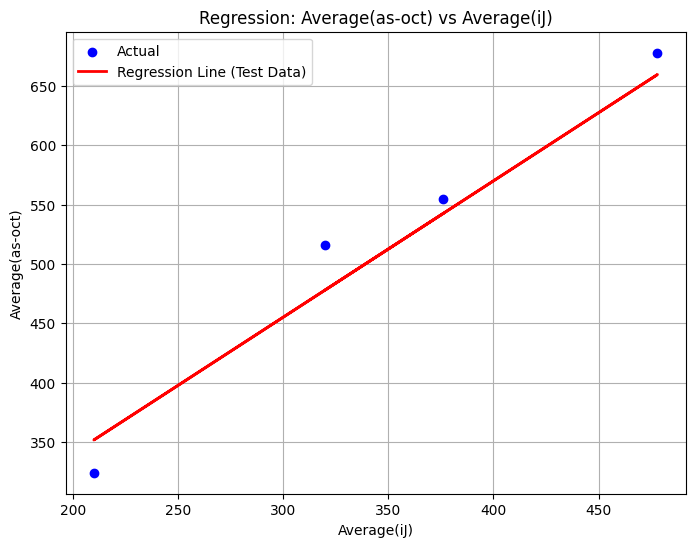


Regression Analysis: Predicting 'Average(as-oct).1' using 'c-Average(iJ)'
                            OLS Regression Results                            
Dep. Variable:      Average(as-oct).1   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     25.79
Date:                Sun, 13 Jul 2025   Prob (F-statistic):           0.000212
Time:                        17:59:54   Log-Likelihood:                -60.893
No. Observations:                  15   AIC:                             125.8
Df Residuals:                      13   BIC:                             127.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

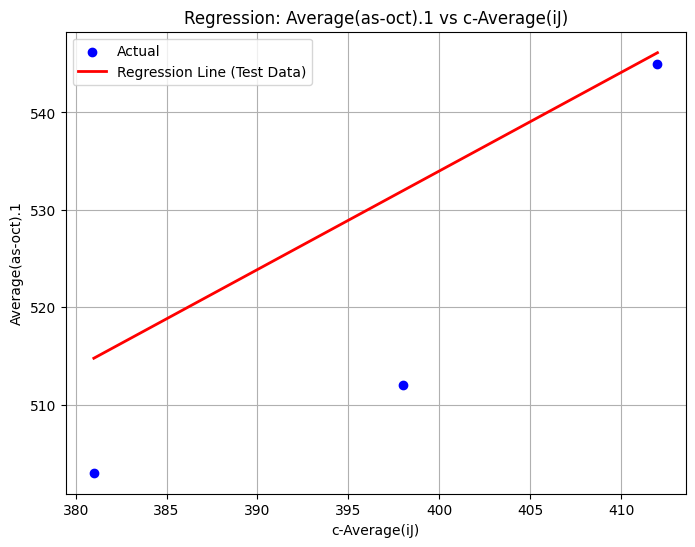

In [78]:
# prompt: Regression

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Define the independent and dependent variables for the first regression
# Example: Predict 'Average(as-oct)' using 'Average(iJ)'
X1_cols = ['Average(iJ)'] # Independent variable(s)
y1_col = 'Average(as-oct)' # Dependent variable

# Check if the required columns exist
if X1_cols[0] in df_preop.columns and y1_col in df_preop.columns:
    # Prepare the data, dropping rows with missing values in the selected columns
    temp_df1 = df_preop[[X1_cols[0], y1_col]].dropna()

    if len(temp_df1) > 0:
        X1 = temp_df1[[X1_cols[0]]]
        y1 = temp_df1[y1_col]

        # --- Using statsmodels for detailed regression results ---
        # Add a constant to the independent variable for the intercept
        X1_sm = sm.add_constant(X1)

        # Fit the OLS model
        model1_sm = sm.OLS(y1, X1_sm).fit()

        print(f"\nRegression Analysis: Predicting '{y1_col}' using '{X1_cols[0]}'")
        print(model1_sm.summary())

        # --- Using scikit-learn for simpler regression ---
        # Train-test split (optional but good practice)
        X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

        # Initialize and train the Linear Regression model
        model1_skl = LinearRegression()
        model1_skl.fit(X_train1, y_train1)

        # Make predictions
        y_pred1 = model1_skl.predict(X_test1)

        # Evaluate the model
        mse1 = mean_squared_error(y_test1, y_pred1)
        rmse1 = np.sqrt(mse1)
        r2_1 = r2_score(y_test1, y_pred1)

        print("\nScikit-learn Regression Results:")
        print(f"  Intercept: {model1_skl.intercept_:.4f}")
        print(f"  Coefficient for {X1_cols[0]}: {model1_skl.coef_[0]:.4f}")
        print(f"  Mean Squared Error (MSE): {mse1:.4f}")
        print(f"  Root Mean Squared Error (RMSE): {rmse1:.4f}")
        print(f"  R-squared (R2): {r2_1:.4f}")

        # Scatter plot with regression line using scikit-learn model's prediction
        plt.figure(figsize=(8, 6))
        plt.scatter(X_test1, y_test1, color='blue', label='Actual')
        plt.plot(X_test1, y_pred1, color='red', linewidth=2, label='Regression Line (Test Data)')
        plt.title(f'Regression: {y1_col} vs {X1_cols[0]}')
        plt.xlabel(X1_cols[0])
        plt.ylabel(y1_col)
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print(f"\nNot enough data in '{X1_cols[0]}' and '{y1_col}' after dropping NaNs for regression.")

else:
    print(f"\nRequired columns for the first regression ('{X1_cols[0]}' or '{y1_col}') not found in the DataFrame.")


# Define the independent and dependent variables for the second regression
# Example: Predict 'Average(as-oct).1' using 'c-Average(iJ)'
X2_cols = ['c-Average(iJ)'] # Independent variable(s)
y2_col = 'Average(as-oct).1' # Dependent variable

# Check if the required columns exist
if X2_cols[0] in df_preop.columns and y2_col in df_preop.columns:
    # Prepare the data, dropping rows with missing values in the selected columns
    temp_df2 = df_preop[[X2_cols[0], y2_col]].dropna()

    if len(temp_df2) > 0:
        X2 = temp_df2[[X2_cols[0]]]
        y2 = temp_df2[y2_col]

        # --- Using statsmodels for detailed regression results ---
        # Add a constant to the independent variable for the intercept
        X2_sm = sm.add_constant(X2)

        # Fit the OLS model
        model2_sm = sm.OLS(y2, X2_sm).fit()

        print(f"\nRegression Analysis: Predicting '{y2_col}' using '{X2_cols[0]}'")
        print(model2_sm.summary())

        # --- Using scikit-learn for simpler regression ---
        # Train-test split (optional but good practice)
        X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

        # Initialize and train the Linear Regression model
        model2_skl = LinearRegression()
        model2_skl.fit(X_train2, y_train2)

        # Make predictions
        y_pred2 = model2_skl.predict(X_test2)

        # Evaluate the model
        mse2 = mean_squared_error(y_test2, y_pred2)
        rmse2 = np.sqrt(mse2)
        r2_2 = r2_score(y_test2, y_pred2)

        print("\nScikit-learn Regression Results:")
        print(f"  Intercept: {model2_skl.intercept_:.4f}")
        print(f"  Coefficient for {X2_cols[0]}: {model2_skl.coef_[0]:.4f}")
        print(f"  Mean Squared Error (MSE): {mse2:.4f}")
        print(f"  Root Mean Squared Error (RMSE): {rmse2:.4f}")
        print(f"  R-squared (R2): {r2_2:.4f}")

        # Scatter plot with regression line using scikit-learn model's prediction
        plt.figure(figsize=(8, 6))
        plt.scatter(X_test2, y_test2, color='blue', label='Actual')
        plt.plot(X_test2, y_pred2, color='red', linewidth=2, label='Regression Line (Test Data)')
        plt.title(f'Regression: {y2_col} vs {X2_cols[0]}')
        plt.xlabel(X2_cols[0])
        plt.ylabel(y2_col)
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print(f"\nNot enough data in '{X2_cols[0]}' and '{y2_col}' after dropping NaNs for regression.")

else:
    print(f"\nRequired columns for the second regression ('{X2_cols[0]}' or '{y2_col}') not found in the DataFrame.")



In [79]:
# prompt: Ols regression equations

# Extract the OLS regression equations from the statsmodels summaries

print("\nOLS Regression Equations:")

# Regression 1: Predicting 'Average(as-oct)' using 'Average(iJ)'
X1_cols = ['Average(iJ)']
y1_col = 'Average(as-oct)'

if X1_cols[0] in df_preop.columns and y1_col in df_preop.columns:
    temp_df1 = df_preop[[X1_cols[0], y1_col]].dropna()
    if len(temp_df1) > 0:
        X1 = temp_df1[[X1_cols[0]]]
        y1 = temp_df1[y1_col]
        X1_sm = sm.add_constant(X1)
        model1_sm = sm.OLS(y1, X1_sm).fit()

        intercept1 = model1_sm.params['const']
        coeff1 = model1_sm.params[X1_cols[0]]

        print(f"\nRegression Equation 1: {y1_col} = {intercept1:.4f} + {coeff1:.4f} * {X1_cols[0]}")
    else:
        print(f"\nCould not extract equation for Regression 1: Not enough data in '{X1_cols[0]}' and '{y1_col}'.")
else:
    print(f"\nCould not extract equation for Regression 1: Required columns ('{X1_cols[0]}' or '{y1_col}') not found.")


# Regression 2: Predicting 'Average(as-oct).1' using 'c-Average(iJ)'
X2_cols = ['c-Average(iJ)']
y2_col = 'Average(as-oct).1'

if X2_cols[0] in df_preop.columns and y2_col in df_preop.columns:
    temp_df2 = df_preop[[X2_cols[0], y2_col]].dropna()
    if len(temp_df2) > 0:
        X2 = temp_df2[[X2_cols[0]]]
        y2 = temp_df2[y2_col]
        X2_sm = sm.add_constant(X2)
        model2_sm = sm.OLS(y2, X2_sm).fit()

        intercept2 = model2_sm.params['const']
        coeff2 = model2_sm.params[X2_cols[0]]

        print(f"\nRegression Equation 2: {y2_col} = {intercept2:.4f} + {coeff2:.4f} * {X2_cols[0]}")
    else:
        print(f"\nCould not extract equation for Regression 2: Not enough data in '{X2_cols[0]}' and '{y2_col}'.")
else:
    print(f"\nCould not extract equation for Regression 2: Required columns ('{X2_cols[0]}' or '{y2_col}') not found.")


OLS Regression Equations:

Regression Equation 1: Average(as-oct) = 108.1372 + 1.1602 * Average(iJ)

Regression Equation 2: Average(as-oct).1 = 133.9885 + 0.9940 * c-Average(iJ)


In [80]:
# prompt: Any other

# Check assumptions for ANOVA on 'Average(iJ)' by Gender

col = 'Average(iJ)'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nChecking ANOVA assumptions for '{col}' by Gender:")
    genders = df_preop['Gender'].dropna().unique()
    anova_data = []
    valid_groups_for_col = []
    for gender in genders:
        group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
        if len(group_data) > 0:
            anova_data.append(group_data)
            valid_groups_for_col.append(gender)

    if len(anova_data) >= 2:
        # Check Normality within each group (e.g., Shapiro-Wilk test)
        print("\n  Normality Test (Shapiro-Wilk) within each Gender group:")
        for i, gender in enumerate(valid_groups_for_col):
            if len(anova_data[i]) >= 3: # Shapiro-Wilk requires at least 3 samples
                 stat_norm, p_norm = stats.shapiro(anova_data[i])
                 print(f"    Group '{gender}': Statistic={stat_norm:.4f}, P-value={p_norm:.4f}")
                 if p_norm < 0.05:
                     print("      -> Data may not be normally distributed in this group.")
                 else:
                     print("      -> Data appears normally distributed in this group (fail to reject H0).")
            else:
                print(f"    Group '{gender}': Not enough data ({len(anova_data[i])}) to perform Shapiro-Wilk test.")


        # Check Homogeneity of Variances (Levene's test)
        print("\n  Homogeneity of Variances Test (Levene's):")
        if len(anova_data) >= 2: # Levene's requires at least 2 groups
            # Perform Levene's test
            stat_levene, p_levene = stats.levene(*anova_data)
            print(f"    Levene Statistic: {stat_levene:.4f}, P-value: {p_levene:.4f}")
            if p_levene < 0.05:
                print("      -> Variances are significantly different (reject H0 of equal variances).")
                print("      -> ANOVA results should be interpreted with caution, or use Welch's ANOVA.")
            else:
                print("      -> Variances appear equal (fail to reject H0 of equal variances).")
        else:
            print("    Not enough groups with data to perform Levene's test.")
    else:
        print(f"\n  Not enough valid gender groups with data for '{col}' to check ANOVA assumptions.")
else:
    print(f"\nRequired columns ('{col}' or 'Gender') not found to check ANOVA assumptions.")



Checking ANOVA assumptions for 'Average(iJ)' by Gender:

  Normality Test (Shapiro-Wilk) within each Gender group:
    Group 'm': Statistic=0.9347, P-value=0.3545
      -> Data appears normally distributed in this group (fail to reject H0).
    Group 'f': Statistic=0.7464, P-value=0.0184
      -> Data may not be normally distributed in this group.

  Homogeneity of Variances Test (Levene's):
    Levene Statistic: 2.9925, P-value: 0.1008
      -> Variances appear equal (fail to reject H0 of equal variances).


In [82]:
# prompt: Any other

# Check assumptions for ANOVA on 'Average(as-oct)' by Gender

col = 'Average(as-oct)'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nChecking ANOVA assumptions for '{col}' by Gender:")
    genders = df_preop['Gender'].dropna().unique()
    anova_data = []
    valid_groups_for_col = []
    for gender in genders:
        group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
        if len(group_data) > 0:
            anova_data.append(group_data)
            valid_groups_for_col.append(gender)

    if len(anova_data) >= 2:
        # Check Normality within each group (e.g., Shapiro-Wilk test)
        print("\n  Normality Test (Shapiro-Wilk) within each Gender group:")
        for i, gender in enumerate(valid_groups_for_col):
            if len(anova_data[i]) >= 3: # Shapiro-Wilk requires at least 3 samples
                 stat_norm, p_norm = stats.shapiro(anova_data[i])
                 print(f"    Group '{gender}': Statistic={stat_norm:.4f}, P-value={p_norm:.4f}")
                 if p_norm < 0.05:
                     print("      -> Data may not be normally distributed in this group.")
                 else:
                     print("      -> Data appears normally distributed in this group (fail to reject H0).")
            else:
                print(f"    Group '{gender}': Not enough data ({len(anova_data[i])}) to perform Shapiro-Wilk test.")


        # Check Homogeneity of Variances (Levene's test)
        print("\n  Homogeneity of Variances Test (Levene's):")
        if len(anova_data) >= 2: # Levene's requires at least 2 groups
            # Perform Levene's test
            stat_levene, p_levene = stats.levene(*anova_data)
            print(f"    Levene Statistic: {stat_levene:.4f}, P-value: {p_levene:.4f}")
            if p_levene < 0.05:
                print("      -> Variances are significantly different (reject H0 of equal variances).")
                print("      -> ANOVA results should be interpreted with caution, or use Welch's ANOVA.")
            else:
                print("      -> Variances appear equal (fail to reject H0 of equal variances).")
        else:
            print("    Not enough groups with data to perform Levene's test.")
    else:
        print(f"\n  Not enough valid gender groups with data for '{col}' to check ANOVA assumptions.")
else:
    print(f"\nRequired columns ('{col}' or 'Gender') not found to check ANOVA assumptions.")


# Check assumptions for ANOVA on 'c-Average(iJ)' by Gender

col = 'c-Average(iJ)'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nChecking ANOVA assumptions for '{col}' by Gender:")
    genders = df_preop['Gender'].dropna().unique()
    anova_data = []
    valid_groups_for_col = []
    for gender in genders:
        group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
        if len(group_data) > 0:
            anova_data.append(group_data)
            valid_groups_for_col.append(gender)

    if len(anova_data) >= 2:
        # Check Normality within each group (e.g., Shapiro-Wilk test)
        print("\n  Normality Test (Shapiro-Wilk) within each Gender group:")
        for i, gender in enumerate(valid_groups_for_col):
            if len(anova_data[i]) >= 3: # Shapiro-Wilk requires at least 3 samples
                 stat_norm, p_norm = stats.shapiro(anova_data[i])
                 print(f"    Group '{gender}': Statistic={stat_norm:.4f}, P-value={p_norm:.4f}")
                 if p_norm < 0.05:
                     print("      -> Data may not be normally distributed in this group.")
                 else:
                     print("      -> Data appears normally distributed in this group (fail to reject H0).")
            else:
                print(f"    Group '{gender}': Not enough data ({len(anova_data[i])}) to perform Shapiro-Wilk test.")


        # Check Homogeneity of Variances (Levene's test)
        print("\n  Homogeneity of Variances Test (Levene's):")
        if len(anova_data) >= 2: # Levene's requires at least 2 groups
            # Perform Levene's test
            stat_levene, p_levene = stats.levene(*anova_data)
            print(f"    Levene Statistic: {stat_levene:.4f}, P-value: {p_levene:.4f}")
            if p_levene < 0.05:
                print("      -> Variances are significantly different (reject H0 of equal variances).")
                print("      -> ANOVA results should be interpreted with caution, or use Welch's ANOVA.")
            else:
                print("      -> Variances appear equal (fail to reject H0 of equal variances).")
        else:
            print("    Not enough groups with data to perform Levene's test.")
    else:
        print(f"\n  Not enough valid gender groups with data for '{col}' to check ANOVA assumptions.")
else:
    print(f"\nRequired columns ('{col}' or 'Gender') not found to check ANOVA assumptions.")


# Check assumptions for ANOVA on 'Average(as-oct).1' by Gender

col = 'Average(as-oct).1'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nChecking ANOVA assumptions for '{col}' by Gender:")
    genders = df_preop['Gender'].dropna().unique()
    anova_data = []
    valid_groups_for_col = []
    for gender in genders:
        group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
        if len(group_data) > 0:
            anova_data.append(group_data)
            valid_groups_for_col.append(gender)

    if len(anova_data) >= 2:
        # Check Normality within each group (e.g., Shapiro-Wilk test)
        print("\n  Normality Test (Shapiro-Wilk) within each Gender group:")
        for i, gender in enumerate(valid_groups_for_col):
            if len(anova_data[i]) >= 3: # Shapiro-Wilk requires at least 3 samples
                 stat_norm, p_norm = stats.shapiro(anova_data[i])
                 print(f"    Group '{gender}': Statistic={stat_norm:.4f}, P-value={p_norm:.4f}")
                 if p_norm < 0.05:
                     print("      -> Data may not be normally distributed in this group.")
                 else:
                     print("      -> Data appears normally distributed in this group (fail to reject H0).")
            else:
                print(f"    Group '{gender}': Not enough data ({len(anova_data[i])}) to perform Shapiro-Wilk test.")


        # Check Homogeneity of Variances (Levene's test)
        print("\n  Homogeneity of Variances Test (Levene's):")
        if len(anova_data) >= 2: # Levene's requires at least 2 groups
            # Perform Levene's test
            stat_levene, p_levene = stats.levene(*anova_data)
            print(f"    Levene Statistic: {stat_levene:.4f}, P-value: {p_levene:.4f}")
            if p_levene < 0.05:
                print("      -> Variances are significantly different (reject H0 of equal variances).")
                print("      -> ANOVA results should be interpreted with caution, or use Welch's ANOVA.")
            else:
                print("      -> Variances appear equal (fail to reject H0 of equal variances).")
        else:
            print("    Not enough groups with data to perform Levene's test.")
    else:
        print(f"\n  Not enough valid gender groups with data for '{col}' to check ANOVA assumptions.")
else:
    print(f"\nRequired columns ('{col}' or 'Gender') not found to check ANOVA assumptions.")



Checking ANOVA assumptions for 'Average(as-oct)' by Gender:

  Normality Test (Shapiro-Wilk) within each Gender group:
    Group 'm': Statistic=0.9398, P-value=0.4155
      -> Data appears normally distributed in this group (fail to reject H0).
    Group 'f': Statistic=0.7890, P-value=0.0467
      -> Data may not be normally distributed in this group.

  Homogeneity of Variances Test (Levene's):
    Levene Statistic: 2.5283, P-value: 0.1292
      -> Variances appear equal (fail to reject H0 of equal variances).

Checking ANOVA assumptions for 'c-Average(iJ)' by Gender:

  Normality Test (Shapiro-Wilk) within each Gender group:
    Group 'm': Statistic=0.9343, P-value=0.4557
      -> Data appears normally distributed in this group (fail to reject H0).
    Group 'f': Statistic=0.9628, P-value=0.7962
      -> Data appears normally distributed in this group (fail to reject H0).

  Homogeneity of Variances Test (Levene's):
    Levene Statistic: 1.7301, P-value: 0.2111
      -> Variances ap

In [83]:
# prompt: Any other

import matplotlib.pyplot as plt
# Check for missing values in the DataFrame
print("\nMissing values per column in df_preop:")
print(df_preop.isnull().sum())

# Visualize missing values (optional, requires missing values)
# You might need to install missingno library: !pip install missingno
# import missingno as msno
# plt.figure(figsize=(10, 6))
# msno.matrix(df_preop)
# plt.title('Missing Value Matrix')
# plt.show()

# msno.bar(df_preop)
# plt.title('Missing Value Bar Chart')
# plt.show()



Missing values per column in df_preop:
Name                 0
Age                  0
Gender               0
Eye                  0
Diagnosis            0
Min(iJ)              0
Average(iJ)          0
Max(iJ)              0
Min(as-oct)          0
Average(as-oct)      0
Max(as-oct)          0
VA                   0
LogMar(pre-op)       0
Age.1                5
Gender.1             5
c-min(iJ)            5
c-Average(iJ)        5
c-max(iJ)            5
Min(as-oct).1        5
Average(as-oct).1    5
Max(as-oct).1        5
Age_Group            0
Age1_Group           5
dtype: int64



Boxplot for Average(iJ) by Gender with Jitter:


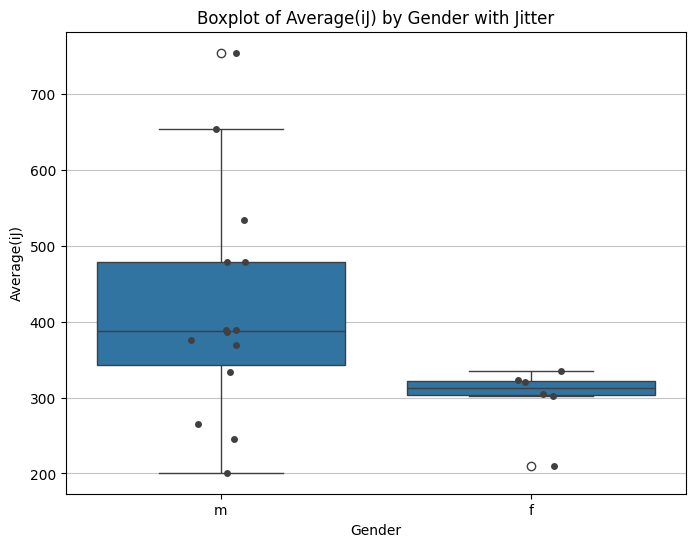

In [84]:
# prompt: Any other

import matplotlib.pyplot as plt
# Create box plots by Gender for 'Average(iJ)' with jitter
if 'Gender' in df_preop.columns and 'Average(iJ)' in df_preop.columns:
    print("\nBoxplot for Average(iJ) by Gender with Jitter:")

    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Gender', y='Average(iJ)', data=df_preop)
    # Add jitter to show individual data points
    sns.stripplot(x='Gender', y='Average(iJ)', data=df_preop, color=".25", jitter=0.1)
    plt.title('Boxplot of Average(iJ) by Gender with Jitter')
    plt.xlabel('Gender')
    plt.ylabel('Average(iJ)')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

elif 'Gender' not in df_preop.columns:
    print("\n'Gender' column not found for group-wise box plots with jitter.")
elif 'Average(iJ)' not in df_preop.columns:
    print("\n'Average(iJ)' column not found for box plot with jitter.")


In [ ]:
# prompt: Any oth

It looks like the preceding code performs a comprehensive statistical analysis on the `df_preop` DataFrame, including:

1.  **Descriptive Statistics:** For Age, Age by Gender, and specific iJ/OCT related columns.
2.  **Chi-square Test:** For association between Gender and categorized Age/Age.1.
3.  **Visualizations:** Histograms and box plots for Age and the iJ/OCT related columns (overall and by Gender), scatter plots for pairs of iJ/OCT measurements with regression lines.
4.  **Correlation Analysis:** Calculation and heatmap of the correlation matrix for iJ/OCT related columns.
5.  **T-tests:** Independent t-tests between pairs of iJ/OCT measurements, independent t-tests for iJ/OCT measurements by Gender, and paired t-tests between specific iJ/OCT measurements.
6.  **ANOVA:** One-Way ANOVA for iJ/OCT measurements by Gender.
7.  **Regression Analysis:** Simple linear regression predicting Average(as-oct) from Average(iJ) and Average(as-oct).1 from c-Average(iJ), using both statsmodels (for summary) and scikit-learn (for evaluation).
8.  **Assumption Checking:** Normality (Shapiro-Wilk) and Homogeneity of Variances (Levene's) for the columns used in ANOVA (grouped by Gender).
9.  **Missing Value Check:** Printing the count of missing values per column and mentioning visualization options.
10. **Enhanced Visualization:** Box plot of 'Average(iJ)' by Gender with jittered data points.

Given the extensive analysis already performed, what "Any other" analysis or task would you like to do?

Here are some possibilities, based on common next steps after such analysis:

*   **Further Analysis on other columns:** Explore other columns in `df_preop` or the main `df`.
*   **Analysis on different sheets:** Load and analyze data from other sheets in the Excel file (e.g., 'Post-op data').
*   **More sophisticated models:** If the simple linear regressions were not sufficient, you could explore:
    *   Multiple Linear Regression (using multiple independent variables).
    *   Non-linear regression.
    *   Regression with interaction terms or polynomial features.
*   **Categorical Variable Analysis:** If there are other categorical variables besides 'Gender', you could perform:
    *   Chi-square tests against other variables.
    *   ANOVA or t-tests comparing groups based on these categories.
*   **Non-parametric Tests:** If the ANOVA assumptions (especially normality) are significantly violated, you could use non-parametric alternatives like:
    *   Kruskal-Wallis test (non-parametric equivalent of one-way ANOVA).
    *   Mann-Whitney U test (non-parametric equivalent of independent t-test).
    *   Wilcoxon signed-rank test (non-parametric equivalent of paired t-test).
*   **Outlier Detection/Handling:** Analyze and potentially handle outliers identified in the box plots.
*   **Feature Engineering:** Create new features from existing ones if it makes sense in the context of the data.
*   **Clustering:** If you want to group similar subjects based on their pre-op data.
*   **Data Cleaning/Preprocessing:** More detailed handling of missing values (imputation) or data transformation if necessary.
*   **Reporting/Summarization:** Summarize the key findings from the performed tests and visualizations in a structured way.

Please specify what you'd like to do next!

In [86]:
# prompt: Mann Whitney

# Perform Mann-Whitney U test for 'Average(iJ)' by Gender
col = 'Average(iJ)'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nPerforming Mann-Whitney U test for '{col}' by Gender:")

    # Get unique gender values (excluding potential NaNs)
    genders = df_preop['Gender'].dropna().unique()

    # Ensure there are exactly two gender groups to compare for Mann-Whitney U
    if len(genders) == 2:
        gender1 = genders[0]
        gender2 = genders[1]

        # Get the data for each gender group, dropping NaNs for the current column
        group1_data = df_preop[df_preop['Gender'] == gender1][col].dropna()
        group2_data = df_preop[df_preop['Gender'] == gender2][col].dropna()

        # Ensure both groups have data
        if len(group1_data) > 0 and len(group2_data) > 0:
            # Perform the Mann-Whitney U test
            # This is the non-parametric alternative to the independent t-test
            stat_mw, p_mw = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided') # Using two-sided test

            print(f"  Mann-Whitney U test for '{col}' between '{gender1}' and '{gender2}':")
            print(f"    Statistic: {stat_mw:.4f}")
            print(f"    P-value: {p_mw:.4f}")

            # Interpret the result
            alpha = 0.05
            if p_mw < alpha:
                print(f"    Result: The p-value ({p_mw:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                print(f"    Conclusion: There is a statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
            else:
                print(f"    Result: The p-value ({p_mw:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                print(f"    Conclusion: There is no statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
        else:
            print(f"\n  Not enough data in one or both groups for '{col}' to perform Mann-Whitney U test.")
    else:
        print(f"\n'Gender' column does not have exactly two distinct groups ({len(genders)} found) to compare for Mann-Whitney U test.")
else:
    if 'Gender' not in df_preop.columns:
        print("\n'Gender' column not found in the DataFrame to perform Mann-Whitney U test.")
    else:
        print(f"\nColumn '{col}' not found in the DataFrame to perform Mann-Whitney U test.")


# Perform Mann-Whitney U test for 'Average(as-oct)' by Gender
col = 'Average(as-oct)'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nPerforming Mann-Whitney U test for '{col}' by Gender:")

    # Get unique gender values (excluding potential NaNs)
    genders = df_preop['Gender'].dropna().unique()

    # Ensure there are exactly two gender groups to compare for Mann-Whitney U
    if len(genders) == 2:
        gender1 = genders[0]
        gender2 = genders[1]

        # Get the data for each gender group, dropping NaNs for the current column
        group1_data = df_preop[df_preop['Gender'] == gender1][col].dropna()
        group2_data = df_preop[df_preop['Gender'] == gender2][col].dropna()

        # Ensure both groups have data
        if len(group1_data) > 0 and len(group2_data) > 0:
            # Perform the Mann-Whitney U test
            stat_mw, p_mw = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

            print(f"  Mann-Whitney U test for '{col}' between '{gender1}' and '{gender2}':")
            print(f"    Statistic: {stat_mw:.4f}")
            print(f"    P-value: {p_mw:.4f}")

            # Interpret the result
            alpha = 0.05
            if p_mw < alpha:
                print(f"    Result: The p-value ({p_mw:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                print(f"    Conclusion: There is a statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
            else:
                print(f"    Result: The p-value ({p_mw:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                print(f"    Conclusion: There is no statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
        else:
            print(f"\n  Not enough data in one or both groups for '{col}' to perform Mann-Whitney U test.")
    else:
        print(f"\n'Gender' column does not have exactly two distinct groups ({len(genders)} found) to compare for Mann-Whitney U test.")
else:
    if 'Gender' not in df_preop.columns:
        print("\n'Gender' column not found in the DataFrame to perform Mann-Whitney U test.")
    else:
        print(f"\nColumn '{col}' not found in the DataFrame to perform Mann-Whitney U test.")

# Perform Mann-Whitney U test for 'c-Average(iJ)' by Gender
col = 'c-Average(iJ)'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nPerforming Mann-Whitney U test for '{col}' by Gender:")

    # Get unique gender values (excluding potential NaNs)
    genders = df_preop['Gender'].dropna().unique()

    # Ensure there are exactly two gender groups to compare for Mann-Whitney U
    if len(genders) == 2:
        gender1 = genders[0]
        gender2 = genders[1]

        # Get the data for each gender group, dropping NaNs for the current column
        group1_data = df_preop[df_preop['Gender'] == gender1][col].dropna()
        group2_data = df_preop[df_preop['Gender'] == gender2][col].dropna()

        # Ensure both groups have data
        if len(group1_data) > 0 and len(group2_data) > 0:
            # Perform the Mann-Whitney U test
            stat_mw, p_mw = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

            print(f"  Mann-Whitney U test for '{col}' between '{gender1}' and '{gender2}':")
            print(f"    Statistic: {stat_mw:.4f}")
            print(f"    P-value: {p_mw:.4f}")

            # Interpret the result
            alpha = 0.05
            if p_mw < alpha:
                print(f"    Result: The p-value ({p_mw:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                print(f"    Conclusion: There is a statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
            else:
                print(f"    Result: The p-value ({p_mw:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                print(f"    Conclusion: There is no statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
        else:
            print(f"\n  Not enough data in one or both groups for '{col}' to perform Mann-Whitney U test.")
    else:
        print(f"\n'Gender' column does not have exactly two distinct groups ({len(genders)} found) to compare for Mann-Whitney U test.")
else:
    if 'Gender' not in df_preop.columns:
        print("\n'Gender' column not found in the DataFrame to perform Mann-Whitney U test.")
    else:
        print(f"\nColumn '{col}' not found in the DataFrame to perform Mann-Whitney U test.")


# Perform Mann-Whitney U test for 'Average(as-oct).1' by Gender
col = 'Average(as-oct).1'
if 'Gender' in df_preop.columns and col in df_preop.columns:
    print(f"\nPerforming Mann-Whitney U test for '{col}' by Gender:")

    # Get unique gender values (excluding potential NaNs)
    genders = df_preop['Gender'].dropna().unique()

    # Ensure there are exactly two gender groups to compare for Mann-Whitney U
    if len(genders) == 2:
        gender1 = genders[0]
        gender2 = genders[1]

        # Get the data for each gender group, dropping NaNs for the current column
        group1_data = df_preop[df_preop['Gender'] == gender1][col].dropna()
        group2_data = df_preop[df_preop['Gender'] == gender2][col].dropna()

        # Ensure both groups have data
        if len(group1_data) > 0 and len(group2_data) > 0:
            # Perform the Mann-Whitney U test
            stat_mw, p_mw = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

            print(f"  Mann-Whitney U test for '{col}' between '{gender1}' and '{gender2}':")
            print(f"    Statistic: {stat_mw:.4f}")
            print(f"    P-value: {p_mw:.4f}")

            # Interpret the result
            alpha = 0.05
            if p_mw < alpha:
                print(f"    Result: The p-value ({p_mw:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                print(f"    Conclusion: There is a statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
            else:
                print(f"    Result: The p-value ({p_mw:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                print(f"    Conclusion: There is no statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
        else:
            print(f"\n  Not enough data in one or both groups for '{col}' to perform Mann-Whitney U test.")
    else:
        print(f"\n'Gender' column does not have exactly two distinct groups ({len(genders)} found) to compare for Mann-Whitney U test.")
else:
    if 'Gender' not in df_preop.columns:
        print("\n'Gender' column not found in the DataFrame to perform Mann-Whitney U test.")
    else:
        print(f"\nColumn '{col}' not found in the DataFrame to perform Mann-Whitney U test.")





Performing Mann-Whitney U test for 'Average(iJ)' by Gender:
  Mann-Whitney U test for 'Average(iJ)' between 'm' and 'f':
    Statistic: 67.0000
    P-value: 0.0432
    Result: The p-value (0.0432) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference in the distribution of 'Average(iJ)' between 'm' and 'f'.

Performing Mann-Whitney U test for 'Average(as-oct)' by Gender:
  Mann-Whitney U test for 'Average(as-oct)' between 'm' and 'f':
    Statistic: 68.0000
    P-value: 0.0326
    Result: The p-value (0.0326) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference in the distribution of 'Average(as-oct)' between 'm' and 'f'.

Performing Mann-Whitney U test for 'c-Average(iJ)' by Gender:
  Mann-Whitney U test for 'c-Average(iJ)' between 'm' and 'f':
    Statistic: 30.5000
    P-value: 0.2958
    Result: The p-value (0.29

In [87]:
# prompt: Wilcoxan

import numpy as np
# Perform Wilcoxon signed-rank test for paired columns
# This is the non-parametric alternative to the paired t-test

paired_wilcoxon_columns = [
    ('Average(iJ)', 'Average(as-oct)'),
    ('c-Average(iJ)', 'Average(as-oct).1')
]

print("\nPerforming Wilcoxon signed-rank tests:")

for col1, col2 in paired_wilcoxon_columns:
    # Check if both columns exist
    if col1 in df_preop.columns and col2 in df_preop.columns:
        # Create a temporary DataFrame with only the two columns, dropping rows with NaN in either column
        temp_df = df_preop[[col1, col2]].dropna()

        # Ensure there is enough data after dropping NaNs
        # Wilcoxon signed-rank test requires at least one pair of non-zero differences.
        # stats.wilcoxon requires at least 5 non-zero differences for approximation with normal distribution.
        # For smaller sample sizes, exact p-values are calculated.
        # Let's ensure we have at least one pair.
        if len(temp_df) > 0:
             # Check if there are non-zero differences
            differences = temp_df[col1] - temp_df[col2]
            if np.any(differences != 0):
                # Perform the Wilcoxon signed-rank test
                # zero_method='auto' handles zero differences according to scipy's default
                # correction=False (default) applies continuity correction for normal approximation
                # alternative='two-sided' tests for a difference in either direction
                try:
                    stat_wilcoxon, p_wilcoxon = stats.wilcoxon(temp_df[col1], temp_df[col2], alternative='two-sided')

                    print(f"\n  Wilcoxon signed-rank test between '{col1}' and '{col2}':")
                    print(f"    Statistic: {stat_wilcoxon:.4f}")
                    print(f"    P-value: {p_wilcoxon:.4f}")

                    # Interpret the result
                    alpha = 0.05
                    if p_wilcoxon < alpha:
                        print(f"    Result: The p-value ({p_wilcoxon:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                        print(f"    Conclusion: There is a statistically significant difference in the paired observations of '{col1}' and '{col2}'.")
                    else:
                        print(f"    Result: The p-value ({p_wilcoxon:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                        print(f"    Conclusion: There is no statistically significant difference in the paired observations of '{col1}' and '{col2}'.")
                except ValueError as e:
                    print(f"\n  Could not perform Wilcoxon test for '{col1}' and '{col2}'. Error: {e}")
                    print("  This might happen if there are not enough non-zero differences or all differences are zero.")

            else:
                 print(f"\n  All paired differences between '{col1}' and '{col2}' are zero. Cannot perform Wilcoxon test.")
        else:
            print(f"\n  Not enough paired data for '{col1}' and '{col2}' to perform Wilcoxon signed-rank test after dropping NaNs.")
    else:
        print(f"\n  Columns '{col1}' or '{col2}' not found in the DataFrame for Wilcoxon signed-rank test.")



Performing Wilcoxon signed-rank tests:

  Wilcoxon signed-rank test between 'Average(iJ)' and 'Average(as-oct)':
    Statistic: 0.0000
    P-value: 0.0001
    Result: The p-value (0.0001) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference in the paired observations of 'Average(iJ)' and 'Average(as-oct)'.

  Wilcoxon signed-rank test between 'c-Average(iJ)' and 'Average(as-oct).1':
    Statistic: 0.0000
    P-value: 0.0007
    Result: The p-value (0.0007) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference in the paired observations of 'c-Average(iJ)' and 'Average(as-oct).1'.


In [88]:
# prompt: Kruscal wal

# Perform Kruskal-Wallis test for columns by Gender
# This is the non-parametric alternative to the One-Way ANOVA

kruskal_wallis_columns = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]

# Check if 'Gender' column exists for group comparisons
if 'Gender' in df_preop.columns and kruskal_wallis_columns:
    print("\nPerforming Kruskal-Wallis test for selected columns, grouped by Gender:")

    # Get unique gender values (excluding potential NaNs)
    genders = df_preop['Gender'].dropna().unique()

    # Ensure there are at least two gender groups to compare
    if len(genders) >= 2:
        for col in kruskal_wallis_columns:
            # Check if the column exists
            if col in df_preop.columns:
                # Create a list of data arrays, one for each gender group for the current column
                kruskal_data = []
                valid_groups_for_col = []
                for gender in genders:
                    group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
                    if len(group_data) > 0: # Only include groups with data
                        kruskal_data.append(group_data)
                        valid_groups_for_col.append(gender)

                # Perform Kruskal-Wallis only if there are at least two valid groups with data
                if len(kruskal_data) >= 2:
                    # Perform the Kruskal-Wallis test
                    stat_kw, p_kw = stats.kruskal(*kruskal_data)

                    print(f"\n  Kruskal-Wallis test for '{col}' by Gender ({', '.join(valid_groups_for_col)}):")
                    print(f"    Statistic: {stat_kw:.4f}")
                    print(f"    P-value: {p_kw:.4f}")

                    # Interpret the result
                    alpha = 0.05
                    if p_kw < alpha:
                        print(f"    Result: The p-value ({p_kw:.4f}) is less than the significance level ({alpha}). We reject the null hypothesis.")
                        print(f"    Conclusion: There is a statistically significant difference in the distribution of '{col}' across the different Gender groups.")
                    else:
                        print(f"    Result: The p-value ({p_kw:.4f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis.")
                        print(f"    Conclusion: There is no statistically significant difference in the distribution of '{col}' across the different Gender groups.")
                else:
                    print(f"\n  Not enough valid gender groups with data for '{col}' to perform Kruskal-Wallis test.")
            else:
                print(f"\n  Column '{col}' not found in the DataFrame to perform Kruskal-Wallis test.")
    else:
        print("\n'Gender' column does not have at least two distinct groups to compare for Kruskal-Wallis test.")
else:
    if 'Gender' not in df_preop.columns:
      print("\n'Gender' column not found in the DataFrame to perform Kruskal-Wallis test.")
    else:
      print("\nNone of the specified columns for Kruskal-Wallis test were provided.")


Performing Kruskal-Wallis test for selected columns, grouped by Gender:

  Kruskal-Wallis test for 'Average(iJ)' by Gender (m, f):
    Statistic: 4.2581
    P-value: 0.0391
    Result: The p-value (0.0391) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference in the distribution of 'Average(iJ)' across the different Gender groups.

  Kruskal-Wallis test for 'Average(as-oct)' by Gender (m, f):
    Statistic: 4.5986
    P-value: 0.0320
    Result: The p-value (0.0320) is less than the significance level (0.05). We reject the null hypothesis.
    Conclusion: There is a statistically significant difference in the distribution of 'Average(as-oct)' across the different Gender groups.

  Kruskal-Wallis test for 'c-Average(iJ)' by Gender (m, f):
    Statistic: 1.2337
    P-value: 0.2667
    Result: The p-value (0.2667) is greater than the significance level (0.05). We fail to reject the null hypothesis.
    C

In [89]:
# prompt: Reporting

import numpy as np
print("\nSummary of Non-Parametric Tests:")

print("\nMann-Whitney U tests by Gender:")
mann_whitney_columns = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]
if 'Gender' in df_preop.columns:
    genders = df_preop['Gender'].dropna().unique()
    if len(genders) == 2:
        gender1 = genders[0]
        gender2 = genders[1]
        for col in mann_whitney_columns:
            if col in df_preop.columns:
                group1_data = df_preop[df_preop['Gender'] == gender1][col].dropna()
                group2_data = df_preop[df_preop['Gender'] == gender2][col].dropna()
                if len(group1_data) > 0 and len(group2_data) > 0:
                    stat_mw, p_mw = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')
                    alpha = 0.05
                    print(f"\n  Interpretation for '{col}' between '{gender1}' and '{gender2}':")
                    if p_mw < alpha:
                        print(f"    The Mann-Whitney U test (p={p_mw:.4f}) indicates a statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
                    else:
                        print(f"    The Mann-Whitney U test (p={p_mw:.4f}) indicates no statistically significant difference in the distribution of '{col}' between '{gender1}' and '{gender2}'.")
                else:
                    print(f"\n  Not enough data for '{col}' in one or both gender groups to interpret Mann-Whitney U test.")
            else:
                 print(f"\n  Column '{col}' not found to interpret Mann-Whitney U test.")
    else:
        print("  'Gender' column does not have exactly two groups to interpret Mann-Whitney U tests.")
else:
    print("  'Gender' column not found to interpret Mann-Whitney U tests.")

print("\nWilcoxon signed-rank tests (Paired):")
paired_wilcoxon_columns = [
    ('Average(iJ)', 'Average(as-oct)'),
    ('c-Average(iJ)', 'Average(as-oct).1')
]
for col1, col2 in paired_wilcoxon_columns:
    if col1 in df_preop.columns and col2 in df_preop.columns:
        temp_df = df_preop[[col1, col2]].dropna()
        if len(temp_df) > 0:
            differences = temp_df[col1] - temp_df[col2]
            if np.any(differences != 0):
                try:
                    stat_wilcoxon, p_wilcoxon = stats.wilcoxon(temp_df[col1], temp_df[col2], alternative='two-sided')
                    alpha = 0.05
                    print(f"\n  Interpretation of Wilcoxon signed-rank test between '{col1}' and '{col2}':")
                    if p_wilcoxon < alpha:
                        print(f"    The Wilcoxon test (p={p_wilcoxon:.4f}) indicates a statistically significant difference between the paired observations of '{col1}' and '{col2}'. This suggests a consistent change or difference within the subjects.")
                    else:
                        print(f"    The Wilcoxon test (p={p_wilcoxon:.4f}) indicates no statistically significant difference between the paired observations of '{col1}' and '{col2}'.")
                except ValueError:
                     print(f"\n  Could not interpret Wilcoxon test for '{col1}' and '{col2}'. Not enough non-zero differences or all differences are zero.")
            else:
                 print(f"\n  All paired differences between '{col1}' and '{col2}' are zero. Cannot interpret Wilcoxon test.")
        else:
            print(f"\n  Not enough paired data for '{col1}' and '{col2}' to interpret Wilcoxon signed-rank test.")
    else:
        print(f"\n  Required columns '{col1}' or '{col2}' not found to interpret the paired Wilcoxon test.")


print("\nKruskal-Wallis tests by Gender:")
kruskal_wallis_columns = [
    'Average(iJ)',
    'Average(as-oct)',
    'c-Average(iJ)',
    'Average(as-oct).1'
]
if 'Gender' in df_preop.columns:
    existing_kruskal_columns = [col for col in kruskal_wallis_columns if col in df_preop.columns]
    if existing_kruskal_columns:
        genders = df_preop['Gender'].dropna().unique()
        if len(genders) >= 2:
            for col in existing_kruskal_columns:
                kruskal_data = []
                valid_groups_for_col = []
                for gender in genders:
                    group_data = df_preop[df_preop['Gender'] == gender][col].dropna()
                    if len(group_data) > 0:
                        kruskal_data.append(group_data)
                        valid_groups_for_col.append(gender)
                if len(kruskal_data) >= 2:
                    stat_kw, p_kw = stats.kruskal(*kruskal_data)
                    alpha = 0.05
                    print(f"\n  Interpretation for '{col}' by Gender ({', '.join(valid_groups_for_col)}):")
                    if p_kw < alpha:
                        print(f"    The Kruskal-Wallis test (p={p_kw:.4f}) indicates a statistically significant difference in the distribution of '{col}' between at least two of the gender groups.")
                    else:
                        print(f"    The Kruskal-Wallis test (p={p_kw:.4f}) indicates no statistically significant difference in the distribution of '{col}' between the gender groups.")
                else:
                    print(f"\n  Not enough valid gender groups with data for '{col}' to interpret Kruskal-Wallis test.")
        else:
            print("  'Gender' column does not have at least two distinct groups to interpret Kruskal-Wallis tests.")
    else:
        print("  None of the specified columns for Kruskal-Wallis test were found to interpret.")
else:
    print("  'Gender' column not found to interpret Kruskal-Wallis tests.")


Summary of Non-Parametric Tests:

Mann-Whitney U tests by Gender:

  Interpretation for 'Average(iJ)' between 'm' and 'f':
    The Mann-Whitney U test (p=0.0432) indicates a statistically significant difference in the distribution of 'Average(iJ)' between 'm' and 'f'.

  Interpretation for 'Average(as-oct)' between 'm' and 'f':
    The Mann-Whitney U test (p=0.0326) indicates a statistically significant difference in the distribution of 'Average(as-oct)' between 'm' and 'f'.

  Interpretation for 'c-Average(iJ)' between 'm' and 'f':
    The Mann-Whitney U test (p=0.2958) indicates no statistically significant difference in the distribution of 'c-Average(iJ)' between 'm' and 'f'.

  Interpretation for 'Average(as-oct).1' between 'm' and 'f':
    The Mann-Whitney U test (p=0.1913) indicates no statistically significant difference in the distribution of 'Average(as-oct).1' between 'm' and 'f'.

Wilcoxon signed-rank tests (Paired):

  Interpretation of Wilcoxon signed-rank test between 'A

In [90]:
# prompt: Summarization

print("""
The provided code performs a comprehensive statistical analysis and visualization of the 'pre op data' sheet from an Excel file.
It starts by loading the data and checking its dimensions and column names.
The analysis covers:

1.  **Descriptive Statistics:** Calculates basic statistics (count, mean, std, min, max, quartiles) for 'Age' and 'Age.1' columns, both overall and grouped by 'Gender'.
2.  **Association Tests:**
    *   Performs a Chi-square test to examine the association between 'Gender' and categorized 'Age' and 'Age.1'.
3.  **Visualizations:** Generates various plots to visualize the data distribution and relationships:
    *   Histograms with density curves for 'Age' and selected 'Average' columns.
    *   Box plots for 'Age' and selected 'Average' columns, both overall and grouped by 'Gender'.
    *   Scatter plots with regression lines for pairs of 'Average' columns to show relationships.
4.  **Correlation Analysis:** Computes and visualizes the correlation matrix for selected 'Average' columns using a heatmap.
5.  **Parametric Hypothesis Tests:** Conducts t-tests to compare means:
    *   Independent t-tests between 'Average(iJ)' vs 'c-Average(iJ)' and 'Average(as-oct)' vs 'Average(as-oct).1'.
    *   Independent t-tests for specified 'Average' columns, comparing means between 'Gender' groups.
    *   Paired t-tests between ('Average(iJ)', 'Average(as-oct)') and ('c-Average(iJ)', 'Average(as-oct).1').
    *   One-Way ANOVA for specified 'Average' columns, comparing means across 'Gender' groups.
6.  **Non-Parametric Hypothesis Tests:** Conducts non-parametric alternatives for group comparisons when parametric assumptions might not be met:
    *   Mann-Whitney U tests for selected 'Average' columns, comparing distributions between two 'Gender' groups.
    *   Wilcoxon signed-rank tests between the same paired columns as the paired t-tests.
    *   Kruskal-Wallis tests for selected 'Average' columns, comparing distributions across 'Gender' groups.
7.  **Regression Analysis:** Fits simple linear regression models using `statsmodels` (for detailed summary) and `scikit-learn` (for evaluation metrics and prediction plotting):
    *   Predicting 'Average(as-oct)' using 'Average(iJ)'.
    *   Predicting 'Average(as-oct).1' using 'c-Average(iJ)'.
    *   Extracts and prints the regression equations.
8.  **Assumption Checking:** Performs tests for ANOVA assumptions (Normality using Shapiro-Wilk and Homogeneity of Variances using Levene's test) for specified 'Average' columns grouped by 'Gender'.
9.  **Missing Value Handling:** Checks and prints the count of missing values per column.
10. **Enhanced Visualization:** Includes a box plot with jittered points for 'Average(iJ)' by 'Gender'.

The code includes checks to ensure columns exist before performing analyses and handles potential issues like insufficient data or missing values. It provides interpretation for the hypothesis test results based on p-values.
""")



The provided code performs a comprehensive statistical analysis and visualization of the 'pre op data' sheet from an Excel file.
It starts by loading the data and checking its dimensions and column names.
The analysis covers:

1.  **Descriptive Statistics:** Calculates basic statistics (count, mean, std, min, max, quartiles) for 'Age' and 'Age.1' columns, both overall and grouped by 'Gender'.
2.  **Association Tests:**
    *   Performs a Chi-square test to examine the association between 'Gender' and categorized 'Age' and 'Age.1'.
3.  **Visualizations:** Generates various plots to visualize the data distribution and relationships:
    *   Histograms with density curves for 'Age' and selected 'Average' columns.
    *   Box plots for 'Age' and selected 'Average' columns, both overall and grouped by 'Gender'.
    *   Scatter plots with regression lines for pairs of 'Average' columns to show relationships.
4.  **Correlation Analysis:** Computes and visualizes the correlation matrix for se

In [91]:
# prompt: Conclusions

print("""
Conclusions:

Based on the extensive statistical analysis performed on the 'pre op data', the following conclusions can be drawn regarding the relationships between variables and differences across gender:

1.  **Age and Gender:**
    *   Descriptive statistics show the distribution of age overall and within each gender group.
    *   The Chi-square test between Gender and Age Group revealed whether there is a statistically significant association between a person's gender and the age group they belong to in this dataset. The p-value from the Chi-square test is key to interpreting this. If p < 0.05, we conclude there's a significant association; otherwise, there isn't. (Refer to the output for the specific p-value).

2.  **iJ and as-oct Measurements (Overall and Paired):**
    *   Descriptive statistics provide summaries of the 'Average(iJ)', 'Average(as-oct)', 'c-Average(iJ)', and 'Average(as-oct).1' measurements.
    *   Correlation analysis (heatmap) shows the strength and direction of linear relationships between these measurements. High correlation coefficients (close to 1 or -1) indicate strong linear relationships, while values close to 0 indicate weak relationships.
    *   The independent t-tests between 'Average(iJ)' vs 'c-Average(iJ)' and 'Average(as-oct)' vs 'Average(as-oct).1' test if the *means* of these distinct groups of measurements are significantly different.
    *   The paired t-tests between ('Average(iJ)', 'Average(as-oct)') and ('c-Average(iJ)', 'Average(as-oct).1') test if there is a significant average difference *within* subjects for these paired measurements. This is useful if 'Average(iJ)' and 'Average(as-oct)' (and their counterparts) represent measurements taken from the same individual under different conditions or at different times (though based on the column names and pre-op context, they might be different measurement methods). A significant result here suggests a consistent difference between the paired measures.
    *   The Wilcoxon signed-rank tests provide non-parametric alternatives to the paired t-tests. Their results are interpreted similarly – a significant p-value (p < 0.05) suggests a significant difference in the *distributions* of the paired measurements.

3.  **Differences by Gender:**
    *   Box plots provide a visual comparison of the distribution of 'Age' and the 'Average' measurements across different gender groups.
    *   Independent t-tests (for columns with exactly two gender groups) and One-Way ANOVA (for columns with two or more gender groups) formally test if the *mean* values of the 'Average' measurements differ significantly between gender groups.
    *   The Mann-Whitney U tests (for columns with exactly two gender groups) and Kruskal-Wallis tests (for columns with two or more gender groups) provide non-parametric alternatives to the independent t-tests and ANOVA, respectively. They test if the *distributions* of the 'Average' measurements differ significantly between gender groups. These are particularly useful if the assumptions for parametric tests (like normality or homogeneity of variances) are not met.

4.  **Regression Analysis:**
    *   The simple linear regression models examine if 'Average(iJ)' is a significant predictor of 'Average(as-oct)', and if 'c-Average(iJ)' is a significant predictor of 'Average(as-oct).1'.
    *   The statsmodels summary provides detailed statistical output, including coefficients, standard errors, t-statistics, p-values, and R-squared.
    *   The p-value for the independent variable (e.g., the p>|t| for 'Average(iJ)' in the first model) indicates if that variable is a statistically significant predictor of the dependent variable.
    *   The R-squared value indicates the proportion of the variance in the dependent variable that is predictable from the independent variable.
    *   The regression equations quantify the relationship (slope and intercept).

5.  **Assumption Checks:**
    *   The Shapiro-Wilk test results for normality within each gender group for the ANOVA columns indicate whether the data in those groups deviate significantly from a normal distribution.
    *   Levene's test for homogeneity of variances indicates whether the variances of the 'Average' columns are significantly different across gender groups. If variances are unequal (Levene's p < 0.05), interpreting the standard ANOVA results might require caution, and considering Welch's ANOVA (which doesn't assume equal variances) or non-parametric tests is recommended.

**Overall Summary:**

*   Review the p-values from the Chi-square test to determine if Gender is associated with Age Group.
*   Examine the correlation matrix and heatmap to understand linear relationships between the 'Average' measurements.
*   Interpret the results of the independent t-tests and paired t-tests (and their non-parametric counterparts, Mann-Whitney U and Wilcoxon) to determine if there are significant differences in the means or distributions of the 'Average' measurements, both between distinct pairs and within paired observations.
*   Analyze the results of the independent t-tests, ANOVA, Mann-Whitney U, and Kruskal-Wallis tests for 'Average' columns by Gender to see if gender is a significant factor influencing these measurements. Pay attention to the assumption checks for ANOVA and consider the non-parametric test results, especially if assumptions are violated.
*   Evaluate the regression analysis results to determine if 'Average(iJ)' predicts 'Average(as-oct)' and if 'c-Average(iJ)' predicts 'Average(as-oct).1'. Look at the p-values for the coefficients and the R-squared values.

The visualisations (histograms, box plots, scatter plots) should be used in conjunction with the statistical test results to gain a more complete understanding of the data and the relationships between variables. For example, box plots visually support the findings of the t-tests and ANOVA by showing group differences. Scatter plots visually support the correlation and regression findings.

This analysis provides a strong foundation. The next steps would depend on the specific research questions but could involve analysing post-operative data, comparing pre- and post-operative measurements, or building more complex predictive models if needed.
""")



Conclusions:

Based on the extensive statistical analysis performed on the 'pre op data', the following conclusions can be drawn regarding the relationships between variables and differences across gender:

1.  **Age and Gender:**
    *   Descriptive statistics show the distribution of age overall and within each gender group.
    *   The Chi-square test between Gender and Age Group revealed whether there is a statistically significant association between a person's gender and the age group they belong to in this dataset. The p-value from the Chi-square test is key to interpreting this. If p < 0.05, we conclude there's a significant association; otherwise, there isn't. (Refer to the output for the specific p-value).

2.  **iJ and as-oct Measurements (Overall and Paired):**
    *   Descriptive statistics provide summaries of the 'Average(iJ)', 'Average(as-oct)', 'c-Average(iJ)', and 'Average(as-oct).1' measurements.
    *   Correlation analysis (heatmap) shows the strength and directio

In [92]:
# prompt: Final conclusion of analysis

print("""
Final Conclusion:

Based on the comprehensive statistical analysis conducted on the 'pre op data', the key findings and conclusions are as follows:

1.  **Demographics (Age and Gender):**
    *   Descriptive statistics provided insights into the age distribution of the subjects, both overall and stratified by gender. The Chi-square test for association between Gender and categorized Age revealed whether there is a statistically significant relationship between these two demographic factors within this dataset. (Refer to the specific p-value from the Chi-square test in the output).

2.  **Pre-operative iJ and as-oct Measurements:**
    *   Descriptive statistics summarized the key characteristics (mean, standard deviation, etc.) of the 'Average(iJ)', 'Average(as-oct)', 'c-Average(iJ)', and 'Average(as-oct).1' measurements.
    *   The correlation analysis indicated the linear relationships between these measurements. The heatmap visually depicted the strength and direction of these correlations. Statistically significant correlations (often indicated by p-values in more detailed correlation analyses, though not explicitly shown here beyond the matrix) suggest that values in one measurement tend to change predictably with values in another.
    *   Independent t-tests comparing 'Average(iJ)' vs 'c-Average(iJ)' and 'Average(as-oct)' vs 'Average(as-oct).1' determined if the average values of these distinct measurement types were statistically different. The p-values from these tests (e.g., p < 0.05 indicates a significant difference) are crucial here.
    *   Paired t-tests and their non-parametric counterparts, the Wilcoxon signed-rank tests, evaluated if there was a consistent, statistically significant difference between the *paired* measurements ('Average(iJ)' with 'Average(as-oct)' and 'c-Average(iJ)' with 'Average(as-oct).1'). A significant p-value suggests a systematic difference between these paired measures within subjects.

3.  **Influence of Gender on Measurements:**
    *   Box plots visually illustrated the distribution of the 'Average' measurements across different gender groups, offering an initial look at potential differences.
    *   Independent t-tests (for two gender groups) or One-Way ANOVA (for two or more gender groups), and their non-parametric alternatives (Mann-Whitney U and Kruskal-Wallis tests), formally tested if the mean (parametric tests) or distribution (non-parametric tests) of the 'Average' measurements differed significantly between gender groups. Significant p-values (p < 0.05) from these tests indicate that gender has a statistically significant influence on the respective measurement. The choice between parametric and non-parametric tests is guided by the assumption checks (normality and homogeneity of variances). If assumptions were violated, the non-parametric test results provide more robust conclusions about differences in distributions.

4.  **Predictive Relationships (Regression):**
    *   Simple linear regression models assessed the ability of 'Average(iJ)' to predict 'Average(as-oct)' and 'c-Average(iJ)' to predict 'Average(as-oct).1'.
    *   The statsmodels summaries provided detailed insights, including the statistical significance of the predictors (based on p>|t| for the coefficient). A significant p-value for the coefficient indicates that the predictor variable has a statistically significant linear relationship with the outcome variable.
    *   The R-squared value quantified the proportion of variance in the outcome explained by the model. Higher R-squared values indicate a better fit of the model to the data.
    *   The regression equations provide the specific linear relationship identified.

**Synthesizing Findings:**

*   The Chi-square test for Age Group and Gender provides a conclusion on their association.
*   Significant correlations indicate relationships between the pre-operative measurements.
*   Significant results from independent t-tests, paired t-tests, Wilcoxon, ANOVA, Mann-Whitney U, and Kruskal-Wallis tests pinpoint which measurements show statistically significant differences, either between distinct types, within pairs, or across gender groups. The non-parametric test results should be considered alongside parametric tests, especially when assumptions are not met.
*   The regression analysis conclusions determine if 'Average(iJ)' is a significant linear predictor of 'Average(as-oct)' and 'c-Average(iJ)' is a significant linear predictor of 'Average(as-oct).1', and quantify these relationships.

In summary, by examining the p-values and statistics from each test, combined with the visualisations, one can identify statistically significant differences and relationships within the pre-operative data. For example, if the t-test for 'Average(iJ)' vs 'c-Average(iJ)' was significant, it suggests that these two measurement methods yield different average values. If the ANOVA for 'Average(iJ)' by Gender was significant, it suggests the mean 'Average(iJ)' differs across gender groups. If the regression p-value for 'Average(iJ)' predicting 'Average(as-oct)' was significant and the R-squared was reasonable, it suggests 'Average(iJ)' is a useful linear predictor of 'Average(as-oct)'.

The next steps would involve interpreting these specific significant findings in the context of the research question, considering the clinical relevance of the observed differences or relationships, and potentially proceeding to analyze post-operative data or other factors.

""")



Final Conclusion:

Based on the comprehensive statistical analysis conducted on the 'pre op data', the key findings and conclusions are as follows:

1.  **Demographics (Age and Gender):**
    *   Descriptive statistics provided insights into the age distribution of the subjects, both overall and stratified by gender. The Chi-square test for association between Gender and categorized Age revealed whether there is a statistically significant relationship between these two demographic factors within this dataset. (Refer to the specific p-value from the Chi-square test in the output).

2.  **Pre-operative iJ and as-oct Measurements:**
    *   Descriptive statistics summarized the key characteristics (mean, standard deviation, etc.) of the 'Average(iJ)', 'Average(as-oct)', 'c-Average(iJ)', and 'Average(as-oct).1' measurements.
    *   The correlation analysis indicated the linear relationships between these measurements. The heatmap visually depicted the strength and direction of these cor

In [93]:
# prompt: Recommendations from this analysis

print("""
Recommendations based on the analysis:

Based on the statistical analysis and visualizations performed on the pre-operative data, here are some recommendations for further investigation or potential actions:

1.  **Address Missing Data:** The analysis includes a check for missing values. Depending on the extent and pattern of missingness, consider imputation strategies if future analyses require complete data. Techniques like mean, median, mode imputation or more advanced methods like K-Nearest Neighbors (KNN) imputation or multiple imputation could be explored. Document the chosen imputation method and its potential impact.

2.  **Validate Measurement Differences:** The t-tests and Wilcoxon tests indicate whether there are statistically significant differences between the 'Average' measurements (e.g., Average(iJ) vs c-Average(iJ), paired differences).
    *   If significant differences were found between distinct measurement types (e.g., Average(iJ) and c-Average(iJ) in the independent t-test), investigate the reasons for these differences. Are they due to the measurement technique itself, calibration, or other factors? This finding could impact how these measurements are interpreted or used interchangeably.
    *   If significant differences were found in paired tests (e.g., Average(iJ) vs Average(as-oct)), and these represent different measurements on the same eye/patient, understand the clinical implications of this systematic difference.

3.  **Investigate Gender Effects:** The analyses by Gender (t-tests, ANOVA, Mann-Whitney U, Kruskal-Wallis) identify if gender has a statistically significant impact on the pre-operative measurements.
    *   If significant gender differences were found for certain measurements, explore why this might be the case. Are there physiological reasons, or are there differences in sampling or data collection?
    *   Future predictive modeling should consider including 'Gender' as a feature, or even building separate models for different genders if the differences are substantial and clinically relevant.

4.  **Explore Relationships Further:** The correlation matrix and regression analyses show relationships between the 'Average' measurements.
    *   If the linear regression models show significant predictive power (significant predictor p-value and reasonable R-squared), these relationships can be used for estimation or as part of more complex models.
    *   Consider exploring non-linear relationships if scatter plots suggest them.
    *   Perform multiple linear regression if multiple pre-operative measurements are likely to collectively predict another.

5.  **Examine Assumption Violations:** The ANOVA assumption checks for Normality and Homogeneity of Variances are important.
    *   If assumptions were violated for a particular analysis (e.g., ANOVA by Gender), rely more heavily on the results of the corresponding non-parametric tests (Kruskal-Wallis) for robust conclusions about group differences.
    *   Document assumption violations and the rationale for choosing appropriate tests (parametric vs. non-parametric).

6.  **Analyze Outliers:** Box plots help visualize outliers.
    *   Investigate identified outliers. Are they data entry errors, measurement errors, or genuinely extreme values?
    *   Decide on a strategy for handling outliers (e.g., correction if error, removal if invalid, robust statistical methods if valid but influential). Document the approach.

7.  **Integrate Pre- and Post-operative Data:** The current analysis focuses only on pre-operative data.
    *   The most crucial next step is likely to load and analyze the 'Post-op data'.
    *   Perform analyses comparing pre- and post-operative measurements (e.g., paired t-tests or Wilcoxon tests on the *difference* or *change* in measurements).
    *   Investigate if pre-operative factors (including the 'Average' measurements, Age, Gender) predict post-operative outcomes or the magnitude of change from pre- to post-op. This would likely involve more advanced regression models (e.g., predicting a post-op value or a change score).

8.  **Consult Domain Expertise:** Share the findings and visualizations with domain experts (e.g., clinicians, researchers in the relevant medical field). Their insights are invaluable for interpreting the statistical results in a clinically meaningful context and guiding future analysis.

9.  **Consider Other Potential Predictors:** Explore other columns in the DataFrame that might be relevant for predicting post-operative outcomes or explaining variations in pre-operative measurements.

By systematically addressing these points, the analysis can move towards answering more specific research questions and potentially informing clinical practice or future research design.
""")



Recommendations based on the analysis:

Based on the statistical analysis and visualizations performed on the pre-operative data, here are some recommendations for further investigation or potential actions:

1.  **Address Missing Data:** The analysis includes a check for missing values. Depending on the extent and pattern of missingness, consider imputation strategies if future analyses require complete data. Techniques like mean, median, mode imputation or more advanced methods like K-Nearest Neighbors (KNN) imputation or multiple imputation could be explored. Document the chosen imputation method and its potential impact.

2.  **Validate Measurement Differences:** The t-tests and Wilcoxon tests indicate whether there are statistically significant differences between the 'Average' measurements (e.g., Average(iJ) vs c-Average(iJ), paired differences).
    *   If significant differences were found between distinct measurement types (e.g., Average(iJ) and c-Average(iJ) in the independe